Following are the imported libraries, that have been used during the entire project

In [150]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import optuna
from optuna.exceptions import TrialPruned
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import root_mean_squared_error
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.data import DataLoader
import seaborn as sns

In [151]:

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Data has been loaded and checked to see structure and columns of the data

In [152]:
data = pd.read_csv(r"C:\Users\kaifm\Downloads\use_LSTM.csv")
data.head()

,Wind onshore,Solar,Residual_load_lag1,Residual_load_lag2,Residual_load_lag24,Residual_load_3h_avg,Residual_load_24h_avg,date_only,hour_sin,hour_cos,...,is_national_day,is_easter_sunday,is_good_friday,is_easter_monday,is_ascension,is_whit_sunday,is_whit_monday,target_1h,month_sin,month_cos
0,0.321004,0.0,0.694253,0.721312,0.748830,0.708081,0.758781,2022-03-01,0.500000,1.000000,...,0,0,0,0,0,0,0,7068.1,1.0,0.5
1,0.163804,0.0,0.680188,0.694253,0.751374,0.689005,0.753139,2022-03-01,0.629410,0.982963,...,0,0,0,0,0,0,0,7068.7,1.0,0.5
2,0.052840,0.0,0.666020,0.680188,0.749116,0.679285,0.747651,2022-03-01,0.750000,0.933013,...,0,0,0,0,0,0,0,7348.1,1.0,0.5
3,0.051519,0.0,0.666081,0.666020,0.780956,0.684265,0.741945,2022-03-01,0.853553,0.853553,...,0,0,0,0,0,0,0,7821.4,1.0,0.5
4,0.092470,0.0,0.694621,0.666081,0.768994,0.710812,0.740224,2022-03-01,0.933013,0.750000,...,0,0,0,0,0,0,0,7855.1,1.0,0.5


The .Describe() function has been used to get the overall statistics about the dataset

In [153]:
print(data.describe())
print(data.columns)

       Wind onshore         Solar  Residual_load_lag1  Residual_load_lag2  \
count  30673.000000  30673.000000        30673.000000        30673.000000   
mean       0.235490      0.113989            0.598149            0.598153   
std        0.206196      0.184966            0.138995            0.138997   
min        0.000000      0.000000            0.000000            0.000000   
25%        0.079260      0.000000            0.516885            0.516885   
50%        0.161162      0.004140            0.604987            0.604997   
75%        0.342140      0.169509            0.691761            0.691771   
max        1.000000      1.000000            1.000000            1.000000   

       Residual_load_lag24  Residual_load_3h_avg  Residual_load_24h_avg  \
count         30673.000000          30673.000000           30673.000000   
mean              0.598276              0.604130               0.526198   
std               0.139026              0.139724               0.175844   
min   

In [154]:
print(data.shape)

(30673, 34)


In [155]:
base_data = data.copy()
print(base_data.shape)

(30673, 34)


Following are the columns that are not important for our prediction though still present
so we are removing it to remove clutter.

In [156]:
base_data.drop(columns = ['Residual_load_lag1', 'Residual_load_lag2',
       'Residual_load_lag24', 'Residual_load_3h_avg', 'Residual_load_24h_avg', 'date_only'], inplace = True)
print(base_data.shape)

(30673, 28)


This cell splits the full dataset into training, validation, and testing parts using specific row ranges. For each split, it separates the target column (target_1h) from the input features and converts both into PyTorch tensors. These tensors are then wrapped into TensorDataset objects so that each feature row is paired with its correct target value. Finally, the code creates DataLoaders for training, validation, and testing, which load the data in batches of 64. This setup prepares the data in a structured and efficient way for the model to learn, validate its performance, and later evaluate on unseen data.

In [157]:
training_data = base_data.iloc[:18000, :]
validation_data = base_data.iloc[18000:28000, ]
testing_data = base_data.iloc[28000:, : ]
training_y = torch.tensor(training_data[['target_1h']].values, dtype = torch.float32)
training_x = torch.tensor(training_data.drop(columns = ['target_1h'], axis = 1).values, dtype = torch.float32)
validation_y = torch.tensor(validation_data[['target_1h']].values, dtype = torch.float32)
validation_x = torch.tensor(validation_data.drop(columns = ['target_1h'], axis = 1).values, dtype = torch.float32) 
testing_y = torch.tensor(testing_data[['target_1h']].values, dtype = torch.float32)
testing_x = torch.tensor(testing_data.drop(columns = ['target_1h'], axis = 1).values, dtype = torch.float32)
train_set = torch.utils.data.TensorDataset(training_x, training_y)
validation_set = torch.utils.data.TensorDataset(validation_x, validation_y)
test_set = torch.utils.data.TensorDataset(testing_x, testing_y)
train_loader = torch.utils.data.DataLoader(dataset = train_set, batch_size = 64, shuffle = False)
validation_loader = torch.utils.data.DataLoader(dataset = validation_set, batch_size = 64, shuffle = False)
test_loader = torch.utils.data.DataLoader(dataset = test_set, shuffle = False, batch_size = 64)

Following pieces of code initiate the LSTM model and the optimzers, loss function being used and training and testing of the model has also been done

In [158]:
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers = 1):
        super(LSTM, self).__init__()
        self.lstm = nn.LSTM(input_size = input_size, hidden_size = hidden_size, 
                            num_layers = num_layers, batch_first = True)
        self.fc1 = nn.Linear(in_features = hidden_size, out_features = 64)
        self.fc2 = nn.Linear(in_features = 64, out_features = 1)
        self.relu = nn.ReLU()


    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)
        out, (hn, cn) = self.lstm(x)
        out = out[:, -1, :]
        out = self.relu(self.fc1(out))
        out = self.fc2(out)
        return out

In [159]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = LSTM(input_size = 27, hidden_size = 256, num_layers = 2).to(device)
optimizer = torch.optim.Adam(params = model.parameters(), lr = 1e-4)
loss_function = nn.MSELoss()
scheduler = ReduceLROnPlateau(optimizer, mode = 'min', patience = 3, factor = 0.5)#ReduceLRonPlateu

This cell trains the model for 100 epochs and tracks how well it learns. In each epoch, the model is set to training mode and loops through the training data in batches. For every batch, it makes predictions, computes the loss, backpropagates the error, and updates the weights using the optimizer. The average training loss for the epoch is calculated and stored. Then the model switches to evaluation mode, and without updating any weights, it computes the loss on the test set to measure generalization performance. This test loss is also stored, and the learning rate scheduler is updated based on it. After each epoch, the code prints both the training and testing losses so you can see how the model is improving over time.

In [160]:
training_losses = []
lstm_testing_losses = []
patience = 5
min_delta = 1e-4
best_test_loss = float("inf")
counter = 0

for epoch in range(100):
    model.train()
    running_training_loss = 0
    running_testing_loss = 0
    for x_part, y_part in train_loader:
        x_part, y_part = x_part.to(device), y_part.to(device)
        optimizer.zero_grad()
        outputs = model(x_part)
        loss = loss_function(outputs, y_part)
        loss.backward()
        optimizer.step()
        running_training_loss += loss.item()
    error = running_training_loss/len(train_loader)
    training_losses.append(np.sqrt(error))

    model.eval()
    with torch.no_grad():
        for x_part, y_part in test_loader:
            x_part, y_part = x_part.to(device), y_part.to(device)
            outputs = model(x_part)
            loss = loss_function(outputs, y_part)
            running_testing_loss += loss.item()
        final_loss = running_testing_loss/len(test_loader)
        lstm_testing_losses.append(np.sqrt(final_loss))
        scheduler.step(final_loss)
    print(f"Epoch : {epoch + 1} ---- Training Loss : {np.sqrt(error):.4f} ---- Testing Loss : {np.sqrt(final_loss):.4f}")

    if best_test_loss - final_loss > min_delta:
        best_test_loss = final_loss
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print(f"Early stopping at epoch {epoch + 1}")
        break

Epoch : 1 ---- Training Loss : 6709.6114 ---- Testing Loss : 5892.1896
Epoch : 2 ---- Training Loss : 6650.7863 ---- Testing Loss : 5816.2392
Epoch : 3 ---- Training Loss : 6571.7770 ---- Testing Loss : 5734.6949
Epoch : 4 ---- Training Loss : 6481.4829 ---- Testing Loss : 5639.5378
Epoch : 5 ---- Training Loss : 6376.4585 ---- Testing Loss : 5530.0728
Epoch : 6 ---- Training Loss : 6256.8609 ---- Testing Loss : 5406.9680
Epoch : 7 ---- Training Loss : 6123.5307 ---- Testing Loss : 5271.2208
Epoch : 8 ---- Training Loss : 5977.4723 ---- Testing Loss : 5123.9052
Epoch : 9 ---- Training Loss : 5819.7028 ---- Testing Loss : 4966.0876
Epoch : 10 ---- Training Loss : 5651.2002 ---- Testing Loss : 4798.8024
Epoch : 11 ---- Training Loss : 5472.8908 ---- Testing Loss : 4623.0530
Epoch : 12 ---- Training Loss : 5285.6516 ---- Testing Loss : 4439.8233
Epoch : 13 ---- Training Loss : 5090.3238 ---- Testing Loss : 4250.0999
Epoch : 14 ---- Training Loss : 4887.7267 ---- Testing Loss : 4054.8947
E

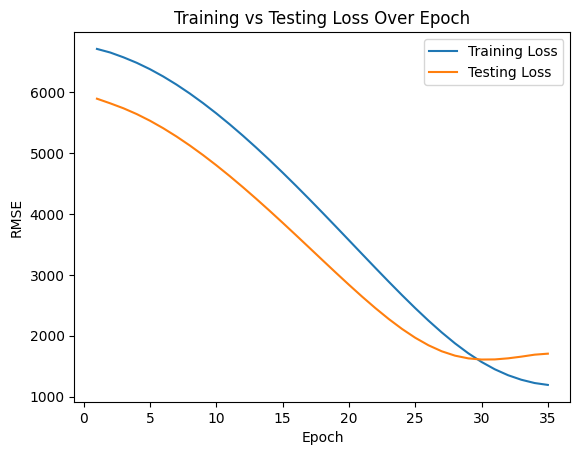

In [161]:
plt.plot(range(1, len(training_losses) + 1), training_losses, label="Training Loss")
plt.plot(range(1, len(training_losses) + 1), lstm_testing_losses, label="Testing Loss")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("Training vs Testing Loss Over Epoch")
plt.legend()
plt.show()

Fine-Tuning of Base LSTM Model

This cell defines the Optuna objective function that tests different hyperparameters for an LSTM model. It lets Optuna choose the learning rate, LSTM hidden size, and optimizer type, then builds a small LSTM network. The model trains for 15 epochs on the training data, updating its weights each batch and clipping gradients for stability. After every epoch, it calculates the validation loss (RMSE) and reports it to Optuna, which can stop the trial early if it performs badly. The final RMSE is returned so Optuna can compare this hyperparameter setup with others

In [162]:
def objective(trial):
    lr = trial.suggest_float('lr', 1e-5, 1e-3)
    fc1_size = trial.suggest_int('fc1_size', 32, 128)
    optimizer_name = trial.suggest_categorical('optimizer', ['Adam', 'SGD', 'RMSprop'])
    
    class LSTM(nn.Module):
        def __init__(self, input_size, hidden_size, num_layers = 1):
            super(LSTM, self).__init__()
            self.lstm = nn.LSTM(input_size = input_size, hidden_size = hidden_size, 
                                num_layers = num_layers, batch_first = True)
            self.fc1 = nn.Linear(in_features = hidden_size, out_features = 64)
            self.fc2 = nn.Linear(in_features = 64, out_features = 1)
            self.relu = nn.ReLU()


        def forward(self, x):
            if x.dim() == 2:
                x = x.unsqueeze(1)
            out, (hn, cn) = self.lstm(x)
            out = out[:, -1, :]
            out = self.relu(self.fc1(out))
            out = self.fc2(out)
            return out
    
    model = LSTM(input_size = 27, hidden_size = fc1_size).to(device)
    if optimizer_name == 'Adam':
        optimizer = torch.optim.Adam(params = model.parameters(), lr = lr)
    elif optimizer_name == 'SGD':
        lr_sgd = trial.suggest_float('lr_sgd', 1e-6, 5e-4)
        optimizer = torch.optim.SGD(params = model.parameters(), lr = lr_sgd, momentum = 0.9)
    else:
        optimizer = torch.optim.RMSprop(params = model.parameters(), lr = lr, weight_decay = 1e-4, alpha = 0.99)
    
    loss_function = nn.MSELoss()
    
    for epoch in range(15):
        model.train()
        for x_part, y_part in train_loader:
            x_part, y_part = x_part.to(device), y_part.to(device)
            optimizer.zero_grad()
            outputs = model(x_part)
            loss = loss_function(outputs, y_part)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()


        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x_part, y_part in validation_loader:
                x_part, y_part = x_part.to(device), y_part.to(device)
                outputs = model(x_part)
                loss = loss_function(outputs, y_part)
                val_loss += loss.item()
        val_loss /= len(validation_loader)
        rmse = np.sqrt(val_loss)
        trial.report(rmse, step = epoch)
        if trial.should_prune():
            raise TrialPruned()
    return rmse

In [163]:
study = optuna.create_study(direction = 'minimize')
study.optimize(objective, n_trials = 50)
print("Best hyperparameters : ")
print(study.best_params)
print("RMSE : ")
print(study.best_value)

[I 2026-01-25 17:29:30,034] A new study created in memory with name: no-name-8316c95e-22e1-44f0-adc1-98df34209d68
[I 2026-01-25 17:29:39,134] Trial 0 finished with value: 6350.616942796985 and parameters: {'lr': 5.4579649824363834e-05, 'fc1_size': 37, 'optimizer': 'Adam'}. Best is trial 0 with value: 6350.616942796985.
[I 2026-01-25 17:29:47,917] Trial 1 finished with value: 1178.155805532474 and parameters: {'lr': 0.0008220780792138999, 'fc1_size': 61, 'optimizer': 'Adam'}. Best is trial 1 with value: 1178.155805532474.
[I 2026-01-25 17:29:56,253] Trial 2 finished with value: 6380.472642377475 and parameters: {'lr': 0.00022540734269687308, 'fc1_size': 50, 'optimizer': 'SGD', 'lr_sgd': 9.290025617686288e-05}. Best is trial 1 with value: 1178.155805532474.
[I 2026-01-25 17:30:04,994] Trial 3 finished with value: 1455.5467199923244 and parameters: {'lr': 0.0007100132681107535, 'fc1_size': 60, 'optimizer': 'RMSprop'}. Best is trial 1 with value: 1178.155805532474.
[I 2026-01-25 17:30:13,7

Best hyperparameters : 
{'lr': 0.0009994014986154053, 'fc1_size': 87, 'optimizer': 'RMSprop'}
RMSE : 
915.1478418008246


Following code plots the optimization history of Fine-Tuning Process

In [164]:
optuna.visualization.plot_optimization_history(study).show()

Following code plots the importances of parameters for better result of the model

In [165]:
optuna.visualization.plot_param_importances(study).show()

Following split has been made to check the fine-tuned model on only Training set(Training + Validation) and Testing Set

In [166]:
training_data = base_data.iloc[:28000, :]
testing_data = base_data.iloc[28000:, : ]
training_y = torch.tensor(training_data[['target_1h']].values, dtype = torch.float32)
training_x = torch.tensor(training_data.drop(columns = ['target_1h'], axis = 1).values, dtype = torch.float32) 
testing_y = torch.tensor(testing_data[['target_1h']].values, dtype = torch.float32)
testing_x = torch.tensor(testing_data.drop(columns = ['target_1h'], axis = 1).values, dtype = torch.float32)
train_set = torch.utils.data.TensorDataset(training_x, training_y)
test_set = torch.utils.data.TensorDataset(testing_x, testing_y)
train_loader2 = torch.utils.data.DataLoader(dataset = train_set, batch_size = 64, shuffle = False)
test_loader2 = torch.utils.data.DataLoader(dataset = test_set, shuffle = False, batch_size = 64)

This cell loads the best hyperparameters found by Optuna and rebuilds the LSTM model using them. It selects the matching optimizer, sets the loss function, and then trains the model for 100 epochs. Each epoch runs through the training data, computes the loss, backpropagates, clips gradients, and updates the weights. After training each epoch, the model is evaluated on the test set without updating weights. The RMSE for both training and testing is stored, and the losses for the epoch are printed so you can track how the model improves.

In [167]:
lr = study.best_params['lr']
hidden_size = study.best_params['fc1_size']
optimizer = study.best_params['optimizer']
model = LSTM(input_size = 27, hidden_size = hidden_size,  num_layers = 2).to(device)
if optimizer == 'Adam':
    optimizer = torch.optim.Adam(params = model.parameters(), lr = lr, weight_decay = 1e-4)
elif optimizer == 'SGD':
    optimizer = torch.optim.SGD(params = model.parameters(), lr = lr, momentum = 0.9, weight_decay = 1e-4)
else:
    optimizer = torch.optim.RMSprop(params = model.parameters(), lr = lr, weight_decay = 1e-4, alpha = 0.99)

loss_function = nn.MSELoss()
train_losses = []
tuned_lstm_test_losses = []
patience = 5
min_delta = 1e-4
best_test_loss = float("inf")
counter = 0

for epoch in range(100):
    model.train()
    running_training_loss = 0
    running_testing_loss = 0
    for x_part, y_part in train_loader2:
        x_part, y_part = x_part.to(device), y_part.to(device)
        optimizer.zero_grad()
        outputs = model(x_part)
        loss = loss_function(outputs, y_part)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        running_training_loss += loss.item()
    error = running_training_loss/len(train_loader2)
    train_losses.append(np.sqrt(error))

    model.eval()
    with torch.no_grad():
        for x_part, y_part in test_loader2:
            x_part, y_part = x_part.to(device), y_part.to(device)
            outputs = model(x_part)
            loss = loss_function(outputs, y_part)
            running_testing_loss += loss.item()
        final_loss = running_testing_loss/len(test_loader2)
        tuned_lstm_test_losses.append(np.sqrt(final_loss))
    print(f"Epoch : {epoch + 1} ---- Training Loss : {np.sqrt(error):.4f} ---- Testing Loss : {np.sqrt(final_loss):.4f}")
    if best_test_loss - final_loss > min_delta:
        best_test_loss = final_loss
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print(f"Early stopping at epoch {epoch + 1}")
        break

Epoch : 1 ---- Training Loss : 6302.0046 ---- Testing Loss : 5167.8807
Epoch : 2 ---- Training Loss : 5091.3416 ---- Testing Loss : 3514.9784
Epoch : 3 ---- Training Loss : 3040.3222 ---- Testing Loss : 1676.0975
Epoch : 4 ---- Training Loss : 1266.6960 ---- Testing Loss : 1068.4735
Epoch : 5 ---- Training Loss : 915.7204 ---- Testing Loss : 856.8114
Epoch : 6 ---- Training Loss : 813.3432 ---- Testing Loss : 890.1948
Epoch : 7 ---- Training Loss : 746.9312 ---- Testing Loss : 932.1722
Epoch : 8 ---- Training Loss : 710.1937 ---- Testing Loss : 1031.5710
Epoch : 9 ---- Training Loss : 694.1839 ---- Testing Loss : 1128.0182
Epoch : 10 ---- Training Loss : 682.9238 ---- Testing Loss : 1195.8783
Early stopping at epoch 10


Following plot shows the performance of fine-tuned model 

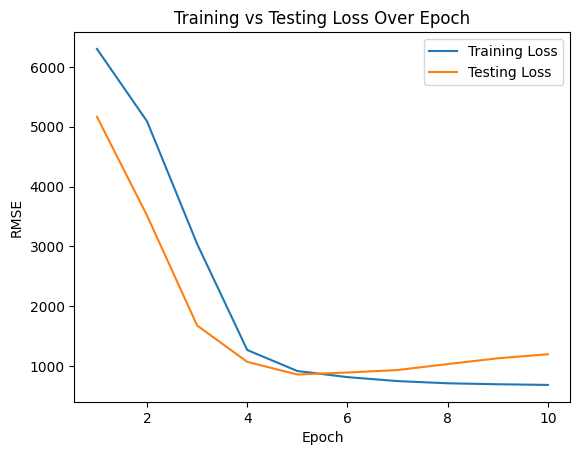

In [168]:
plt.plot(range(1, len(train_losses) + 1), train_losses, label="Training Loss")
plt.plot(range(1, len(train_losses) + 1), tuned_lstm_test_losses, label="Testing Loss")
plt.xlabel("Epoch") 
plt.ylabel("RMSE")
plt.title("Training vs Testing Loss Over Epoch")
plt.legend()
plt.show()

LSTM with Lagged Features

In [169]:
usable_data = data.copy()
usable_data.drop(columns = ['date_only'], inplace = True)

In [170]:
usable_data.columns

Index(['Wind onshore', 'Solar', 'Residual_load_lag1', 'Residual_load_lag2',
       'Residual_load_lag24', 'Residual_load_3h_avg', 'Residual_load_24h_avg',
       'hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos', 'is_weekend',
       'is_holiday', 'temperature_C', 'wind_speed', 'solar_rad', 'precip_mm',
       'snow_cover_pct', 'snowfall_mm', 'is_christmas', 'is_stephanstag',
       'is_new_year', 'is_epiphany', 'is_national_day', 'is_easter_sunday',
       'is_good_friday', 'is_easter_monday', 'is_ascension', 'is_whit_sunday',
       'is_whit_monday', 'target_1h', 'month_sin', 'month_cos'],
      dtype='object')

In [171]:
usable_data.shape

(30673, 33)

Following code splits the data into Training, Validation, and Testing set and making it suitable for the Deep Learning models according to the torch requirement

In [172]:
training_data = usable_data.iloc[:18000, :]
validation_data = usable_data.iloc[18000:28000, ]
testing_data = usable_data.iloc[28000:, : ]
training_y = torch.tensor(training_data[['target_1h']].values, dtype = torch.float32)
training_x = torch.tensor(training_data.drop(columns = ['target_1h'], axis = 1).values, dtype = torch.float32)
validation_y = torch.tensor(validation_data[['target_1h']].values, dtype = torch.float32)
validation_x = torch.tensor(validation_data.drop(columns = ['target_1h'], axis = 1).values, dtype = torch.float32) 
testing_y = torch.tensor(testing_data[['target_1h']].values, dtype = torch.float32)
testing_x = torch.tensor(testing_data.drop(columns = ['target_1h'], axis = 1).values, dtype = torch.float32)
train_set = torch.utils.data.TensorDataset(training_x, training_y)
validation_set = torch.utils.data.TensorDataset(validation_x, validation_y)
test_set = torch.utils.data.TensorDataset(testing_x, testing_y)
train_loader = torch.utils.data.DataLoader(dataset = train_set, batch_size = 64, shuffle = False)
validation_loader = torch.utils.data.DataLoader(dataset = validation_set, batch_size = 64, shuffle = False)
test_loader = torch.utils.data.DataLoader(dataset = test_set, shuffle = False, batch_size = 64)

In [173]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = LSTM(input_size = 32, hidden_size = 256, num_layers = 2).to(device)
optimizer = torch.optim.Adam(params = model.parameters(), lr = 1e-4)
loss_function = nn.MSELoss()
scheduler = ReduceLROnPlateau(optimizer, mode = 'min', patience = 3, factor = 0.5)#ReduceLRonPlateu

Following code trains the LSTM model with lagged features

In [174]:
training_losses = []
lagged_lstm_testing_losses = []
patience = 5
min_delta = 1e-4
best_test_loss = float("inf")
counter = 0

for epoch in range(100):
    model.train()
    running_training_loss = 0
    running_testing_loss = 0
    for x_part, y_part in train_loader:
        x_part, y_part = x_part.to(device), y_part.to(device)
        optimizer.zero_grad()
        outputs = model(x_part)
        loss = loss_function(outputs, y_part)
        loss.backward()
        optimizer.step()
        running_training_loss += loss.item()
    error = running_training_loss/len(train_loader)
    training_losses.append(np.sqrt(error))

    model.eval()
    with torch.no_grad():
        for x_part, y_part in test_loader:
            x_part, y_part = x_part.to(device), y_part.to(device)
            outputs = model(x_part)
            loss = loss_function(outputs, y_part)
            running_testing_loss += loss.item()
        final_loss = running_testing_loss/len(test_loader)
        lagged_lstm_testing_losses.append(np.sqrt(final_loss))
        scheduler.step(final_loss)
    print(f"Epoch : {epoch + 1} ---- Training Loss : {np.sqrt(error):.4f} ---- Testing Loss : {np.sqrt(final_loss):.4f}")
    if best_test_loss - final_loss > min_delta:
        best_test_loss = final_loss
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print(f"Early stopping at epoch {epoch + 1}")
        break

Epoch : 1 ---- Training Loss : 6710.8620 ---- Testing Loss : 5900.4624
Epoch : 2 ---- Training Loss : 6679.7976 ---- Testing Loss : 5863.8915
Epoch : 3 ---- Training Loss : 6640.9719 ---- Testing Loss : 5822.6645
Epoch : 4 ---- Training Loss : 6594.6513 ---- Testing Loss : 5773.2409
Epoch : 5 ---- Training Loss : 6539.7287 ---- Testing Loss : 5715.5220
Epoch : 6 ---- Training Loss : 6476.4209 ---- Testing Loss : 5649.8841
Epoch : 7 ---- Training Loss : 6405.1733 ---- Testing Loss : 5576.8078
Epoch : 8 ---- Training Loss : 6326.4719 ---- Testing Loss : 5496.7807
Epoch : 9 ---- Training Loss : 6240.7855 ---- Testing Loss : 5410.2621
Epoch : 10 ---- Training Loss : 6148.5445 ---- Testing Loss : 5317.6730
Epoch : 11 ---- Training Loss : 6050.1362 ---- Testing Loss : 5219.3953
Epoch : 12 ---- Training Loss : 5945.9070 ---- Testing Loss : 5115.7760
Epoch : 13 ---- Training Loss : 5836.1669 ---- Testing Loss : 5007.1325
Epoch : 14 ---- Training Loss : 5721.1956 ---- Testing Loss : 4893.7606
E

follwing code plots the performance graph of the LSTM with lagged features

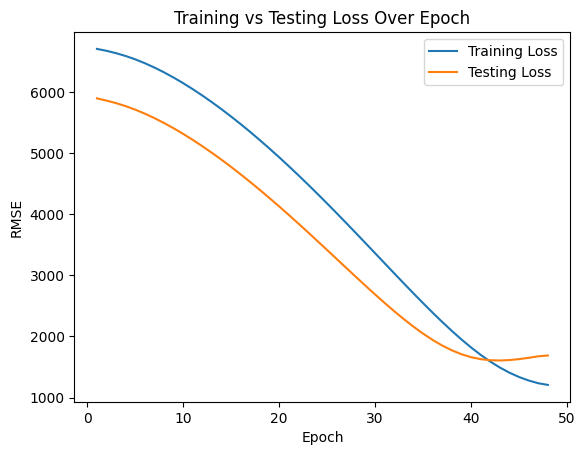

In [175]:
plt.plot(range(1, len(training_losses) + 1), training_losses, label="Training Loss")
plt.plot(range(1, len(training_losses) + 1), lagged_lstm_testing_losses, label="Testing Loss")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("Training vs Testing Loss Over Epoch")
plt.legend()
plt.show()


This cell defines the Optuna objective function that tests different hyperparameters for an LSTM. Optuna selects values for the learning rate, LSTM hidden size, and optimizer type. With these choices, the code builds a small LSTM model and trains it for 15 epochs on the training data. After each epoch, it calculates the validation RMSE and reports it to Optuna. If the trial is performing poorly, Optuna can stop it early. The function returns the final RMSE so Optuna can compare this trial with others.

Lagged Feature LSTM Tuned

In [176]:
def objective(trial):
    lr = trial.suggest_float('lr', 1e-5, 1e-3)
    fc1_size = trial.suggest_int('fc1_size', 32, 128)
    optimizer_name = trial.suggest_categorical('optimizer', ['Adam', 'SGD', 'RMSprop'])
    
    class LSTM(nn.Module):
        def __init__(self, input_size, hidden_size, num_layers = 1):
            super(LSTM, self).__init__()
            self.lstm = nn.LSTM(input_size = input_size, hidden_size = hidden_size, 
                                num_layers = num_layers, batch_first = True)
            self.fc1 = nn.Linear(in_features = hidden_size, out_features = 64)
            self.fc2 = nn.Linear(in_features = 64, out_features = 1)
            self.relu = nn.ReLU()


        def forward(self, x):
            if x.dim() == 2:
                x = x.unsqueeze(1)
            out, (hn, cn) = self.lstm(x)
            out = out[:, -1, :]
            out = self.relu(self.fc1(out))
            out = self.fc2(out)
            return out
    
    model = LSTM(input_size = 32, hidden_size = fc1_size).to(device)
    if optimizer_name == 'Adam':
        optimizer = torch.optim.Adam(params = model.parameters(), lr = lr)
    elif optimizer_name == 'SGD':
        lr_sgd = trial.suggest_float('lr_sgd', 1e-6, 5e-4)
        optimizer = torch.optim.SGD(params = model.parameters(), lr = lr_sgd, momentum = 0.9)
    else:
        optimizer = torch.optim.RMSprop(params = model.parameters(), lr = lr, weight_decay = 1e-4, alpha = 0.99)
    
    loss_function = nn.MSELoss()
    
    for epoch in range(15):
        model.train()
        for x_part, y_part in train_loader:
            x_part, y_part = x_part.to(device), y_part.to(device)
            optimizer.zero_grad()
            outputs = model(x_part)
            loss = loss_function(outputs, y_part)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()


        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x_part, y_part in validation_loader:
                x_part, y_part = x_part.to(device), y_part.to(device)
                outputs = model(x_part)
                loss = loss_function(outputs, y_part)
                val_loss += loss.item()
        val_loss /= len(validation_loader)
        rmse = np.sqrt(val_loss)
        trial.report(rmse, step = epoch)
        if trial.should_prune():
            raise TrialPruned()
    return rmse

In [177]:
study = optuna.create_study(direction = 'minimize')
study.optimize(objective, n_trials = 50)
print("Best hyperparameters : ")
print(study.best_params)
print("RMSE : ")
print(study.best_value)

[I 2026-01-25 17:35:01,109] A new study created in memory with name: no-name-3cd1cdc7-edba-49ae-8e6c-ffeda71146b7
[I 2026-01-25 17:35:10,173] Trial 0 finished with value: 836.2414493698027 and parameters: {'lr': 0.0008882680490588853, 'fc1_size': 109, 'optimizer': 'Adam'}. Best is trial 0 with value: 836.2414493698027.
[I 2026-01-25 17:35:19,017] Trial 1 finished with value: 1559.1422907236304 and parameters: {'lr': 0.0005444373318629754, 'fc1_size': 83, 'optimizer': 'Adam'}. Best is trial 0 with value: 836.2414493698027.
[I 2026-01-25 17:35:29,683] Trial 2 finished with value: 6384.275743131026 and parameters: {'lr': 0.0006837212217508328, 'fc1_size': 42, 'optimizer': 'SGD', 'lr_sgd': 6.427288983800646e-05}. Best is trial 0 with value: 836.2414493698027.
[I 2026-01-25 17:35:39,557] Trial 3 finished with value: 6291.74494291938 and parameters: {'lr': 0.00099445973288263, 'fc1_size': 37, 'optimizer': 'SGD', 'lr_sgd': 0.00026022997466596177}. Best is trial 0 with value: 836.2414493698027

Best hyperparameters : 
{'lr': 0.0009691895421606087, 'fc1_size': 122, 'optimizer': 'RMSprop'}
RMSE : 
772.0317369682068


Following plot shows the Optimization history of the Lagged Feature LSTM model

In [178]:
optuna.visualization.plot_optimization_history(study).show()

Following plot shows the importance of parameters for the Lagged Feature LSTM model

In [179]:
optuna.visualization.plot_param_importances(study).show()

Since now we have already fine-tuned, the data we are combining is Training and Validation set to use it as Training set and Test set remains the same

In [180]:
training_data = usable_data.iloc[:28000, :]
testing_data = usable_data.iloc[28000:, : ]
training_y = torch.tensor(training_data[['target_1h']].values, dtype = torch.float32)
training_x = torch.tensor(training_data.drop(columns = ['target_1h'], axis = 1).values, dtype = torch.float32) 
testing_y = torch.tensor(testing_data[['target_1h']].values, dtype = torch.float32)
testing_x = torch.tensor(testing_data.drop(columns = ['target_1h'], axis = 1).values, dtype = torch.float32)
train_set = torch.utils.data.TensorDataset(training_x, training_y)
test_set = torch.utils.data.TensorDataset(testing_x, testing_y)
train_loader2 = torch.utils.data.DataLoader(dataset = train_set, batch_size = 64, shuffle = False)
test_loader2 = torch.utils.data.DataLoader(dataset = test_set, shuffle = False, batch_size = 64)

This cell rebuilds the LSTM model using the best hyperparameters found by Optuna and trains it fully. It loads the best learning rate, hidden size, and optimizer, creates the final LSTM model, and sets up the loss function. The model then trains for 100 epochs: each epoch updates the weights on the training data and records the training RMSE. After that, the model is evaluated on the test set to compute the test RMSE. Both losses are stored, and the epoch’s results are printed so you can track model performance over time.

In [181]:
lr = study.best_params['lr']
hidden_size = study.best_params['fc1_size']
optimizer = study.best_params['optimizer']
model = LSTM(input_size = 32, hidden_size = hidden_size,  num_layers = 2).to(device)
if optimizer == 'Adam':
    optimizer = torch.optim.Adam(params = model.parameters(), lr = lr, weight_decay = 1e-4)
elif optimizer == 'SGD':
    optimizer = torch.optim.SGD(params = model.parameters(), lr = lr, momentum = 0.9, weight_decay = 1e-4)
else:
    optimizer = torch.optim.RMSprop(params = model.parameters(), lr = lr, weight_decay = 1e-4, alpha = 0.99)

loss_function = nn.MSELoss()
train_losses = []
lagged_tuned_lstm_test_losses = []
patience = 5
min_delta = 1e-4
best_test_loss = float("inf")
counter = 0

for epoch in range(100):
    model.train()
    running_training_loss = 0
    running_testing_loss = 0
    for x_part, y_part in train_loader2:
        x_part, y_part = x_part.to(device), y_part.to(device)
        optimizer.zero_grad()
        outputs = model(x_part)
        loss = loss_function(outputs, y_part)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        running_training_loss += loss.item()
    error = running_training_loss/len(train_loader2)
    train_losses.append(np.sqrt(error))

    model.eval()
    with torch.no_grad():
        for x_part, y_part in test_loader2:
            x_part, y_part = x_part.to(device), y_part.to(device)
            outputs = model(x_part)
            loss = loss_function(outputs, y_part)
            running_testing_loss += loss.item()
        final_loss = running_testing_loss/len(test_loader2)
        lagged_tuned_lstm_test_losses.append(np.sqrt(final_loss))
    print(f"Epoch : {epoch + 1} ---- Training Loss : {np.sqrt(error):.4f} ---- Testing Loss : {np.sqrt(final_loss):.4f}")
    if best_test_loss - final_loss > min_delta:
        best_test_loss = final_loss
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print(f"Early stopping at epoch {epoch + 1}")
        break

Epoch : 1 ---- Training Loss : 6146.1406 ---- Testing Loss : 4778.9262
Epoch : 2 ---- Training Loss : 4368.2096 ---- Testing Loss : 2456.8494
Epoch : 3 ---- Training Loss : 1825.6376 ---- Testing Loss : 909.4564
Epoch : 4 ---- Training Loss : 795.8056 ---- Testing Loss : 788.8061
Epoch : 5 ---- Training Loss : 644.9613 ---- Testing Loss : 804.6750
Epoch : 6 ---- Training Loss : 581.9348 ---- Testing Loss : 787.4402
Epoch : 7 ---- Training Loss : 560.4698 ---- Testing Loss : 769.0680
Epoch : 8 ---- Training Loss : 548.1568 ---- Testing Loss : 760.7183
Epoch : 9 ---- Training Loss : 541.7542 ---- Testing Loss : 765.7345
Epoch : 10 ---- Training Loss : 532.2373 ---- Testing Loss : 750.6528
Epoch : 11 ---- Training Loss : 525.1949 ---- Testing Loss : 732.7771
Epoch : 12 ---- Training Loss : 516.8234 ---- Testing Loss : 732.5482
Epoch : 13 ---- Training Loss : 510.2097 ---- Testing Loss : 728.1252
Epoch : 14 ---- Training Loss : 503.0859 ---- Testing Loss : 714.7151
Epoch : 15 ---- Training

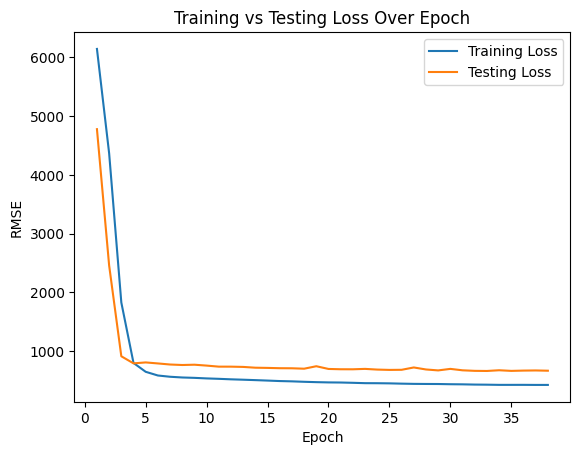

In [182]:
plt.plot(range(1, len(train_losses) + 1), train_losses, label="Training Loss")
plt.plot(range(1, len(train_losses) + 1), lagged_tuned_lstm_test_losses, label="Testing Loss")
plt.xlabel("Epoch") 
plt.ylabel("RMSE")
plt.title("Training vs Testing Loss Over Epoch")
plt.legend()
plt.show()

CNN + LSTM

In [54]:
data2 = pd.read_csv(r"C:\Users\kaifm\Downloads\InputLoadLSTM_CNN_Targets.csv")
data2.head()

,DateTime,hour_sin,hour_cos,weekday_sin,weekday_cos,is_weekend,is_holiday,is_christmas,is_stephanstag,is_new_year,...,snowfall_mm_scaled,load_lag_1h_scaled,load_lag_2h_scaled,load_lag_24h_scaled,load_3h_avg_scaled,load_24h_avg_scaled,target_residual_1h_scaled,target_load_1h_scaled,target_solar_1h_scaled,target_wind_1h_scaled
0,2022-03-01 00:00:00,0.500000,1.000000,0.900969,0.801938,0,0,0,0,0,...,0.002032,0.445566,0.445566,0.445566,0.453836,0.755238,0.666020,0.430626,0.0,0.163804
1,2022-03-01 01:00:00,0.629410,0.982963,0.900969,0.801938,0,0,0,0,0,...,0.001428,0.445566,0.445566,0.445566,0.453836,0.755238,0.666081,0.429842,0.0,0.052840
2,2022-03-01 02:00:00,0.750000,0.933013,0.900969,0.801938,0,0,0,0,0,...,0.002891,0.430626,0.445566,0.445566,0.453836,0.755238,0.694621,0.457568,0.0,0.051519
3,2022-03-01 03:00:00,0.853553,0.853553,0.900969,0.801938,0,0,0,0,0,...,0.004331,0.429842,0.430626,0.445566,0.458137,0.755238,0.742967,0.504849,0.0,0.092470
4,2022-03-01 04:00:00,0.933013,0.750000,0.900969,0.801938,0,0,0,0,0,...,0.005430,0.457568,0.429842,0.445566,0.484740,0.755238,0.746410,0.509336,0.0,0.243065


In [55]:
data2.describe()

,hour_sin,hour_cos,weekday_sin,weekday_cos,is_weekend,is_holiday,is_christmas,is_stephanstag,is_new_year,is_epiphany,...,snowfall_mm_scaled,load_lag_1h_scaled,load_lag_2h_scaled,load_lag_24h_scaled,load_3h_avg_scaled,load_24h_avg_scaled,target_residual_1h_scaled,target_load_1h_scaled,target_solar_1h_scaled,target_wind_1h_scaled
count,30672.000000,30672.000000,30672.000000,3.067200e+04,30672.000000,30672.000000,30672.000000,30672.000000,30672.000000,30672.000000,...,30672.000000,30672.000000,30672.000000,30672.000000,30672.000000,30672.000000,30672.000000,30672.000000,30672.000000,30672.000000
mean,0.500000,0.500000,0.500705,4.733758e-01,0.284820,0.010955,0.002347,0.002347,0.002347,0.002347,...,0.025249,0.431613,0.431616,0.431579,0.449823,0.581962,0.598144,0.431608,0.113993,0.235487
std,0.353559,0.353559,0.362633,3.719954e-01,0.451336,0.104091,0.048394,0.048394,0.048394,0.048394,...,0.068316,0.106015,0.106014,0.105985,0.110022,0.131082,0.138995,0.106016,0.184968,0.206199
min,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.146447,0.146447,0.099031,5.551115e-17,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.361612,0.361622,0.361622,0.376714,0.496392,0.516882,0.361612,0.000000,0.079260
50%,0.500000,0.500000,0.500000,3.568959e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000122,0.432582,0.432587,0.432632,0.450885,0.568431,0.604987,0.432572,0.004149,0.161162
75%,0.853553,0.853553,0.900969,8.019377e-01,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.013103,0.500474,0.500474,0.500392,0.521229,0.667510,0.691753,0.500474,0.169518,0.342140
max,1.000000,1.000000,1.000000,1.000000e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [56]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30672 entries, 0 to 30671
Data columns (total 43 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   DateTime                   30672 non-null  object 
 1   hour_sin                   30672 non-null  float64
 2   hour_cos                   30672 non-null  float64
 3   weekday_sin                30672 non-null  float64
 4   weekday_cos                30672 non-null  float64
 5   is_weekend                 30672 non-null  int64  
 6   is_holiday                 30672 non-null  int64  
 7   is_christmas               30672 non-null  int64  
 8   is_stephanstag             30672 non-null  int64  
 9   is_new_year                30672 non-null  int64  
 10  is_epiphany                30672 non-null  int64  
 11  is_national_day            30672 non-null  int64  
 12  is_easter_sunday           30672 non-null  int64  
 13  is_good_friday             30672 non-null  int

In [57]:
data2.columns

Index(['DateTime', 'hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos',
       'is_weekend', 'is_holiday', 'is_christmas', 'is_stephanstag',
       'is_new_year', 'is_epiphany', 'is_national_day', 'is_easter_sunday',
       'is_good_friday', 'is_easter_monday', 'is_ascension', 'is_whit_sunday',
       'is_whit_monday', 'target_residual_1h', 'month_sin', 'month_cos',
       'load_orig', 'solar_producation_orig', 'residual_load_orig',
       'wind_production_orig', 'target_load_1h', 'target_solar_1h',
       'target_wind_1h', 'solar_rad_scaled', 'temperature_C_scaled',
       'wind_speed_scaled', 'precip_mm_scaled', 'snow_cover_pct_scaled',
       'snowfall_mm_scaled', 'load_lag_1h_scaled', 'load_lag_2h_scaled',
       'load_lag_24h_scaled', 'load_3h_avg_scaled', 'load_24h_avg_scaled',
       'target_residual_1h_scaled', 'target_load_1h_scaled',
       'target_solar_1h_scaled', 'target_wind_1h_scaled'],
      dtype='object')

In [58]:
data2.shape

(30672, 43)

This cell creates a copy of the main dataset and removes all columns that are not needed for the LSTM model. By dropping these extra timestamp, weather, and target-related fields, the dataset is cleaned and reduced to only the features required for training. This prepares a simpler and focused input set for the LSTM.

In [59]:
lstm_load_data = data2.copy()
lstm_load_data.drop(columns = ['DateTime', 'solar_producation_orig', 'residual_load_orig', 'wind_production_orig', 'precip_mm_scaled', 'snow_cover_pct_scaled',
       'snowfall_mm_scaled',
       'target_residual_1h_scaled', 'target_load_1h_scaled',
       'target_solar_1h_scaled', 'target_wind_1h_scaled', 'target_solar_1h',
       'target_wind_1h', 'residual_load_orig', 'solar_rad_scaled', 'wind_speed_scaled', 'target_residual_1h', 'load_orig'], inplace = True)

In [60]:
lstm_load_data.columns

Index(['hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos', 'is_weekend',
       'is_holiday', 'is_christmas', 'is_stephanstag', 'is_new_year',
       'is_epiphany', 'is_national_day', 'is_easter_sunday', 'is_good_friday',
       'is_easter_monday', 'is_ascension', 'is_whit_sunday', 'is_whit_monday',
       'month_sin', 'month_cos', 'target_load_1h', 'temperature_C_scaled',
       'load_lag_1h_scaled', 'load_lag_2h_scaled', 'load_lag_24h_scaled',
       'load_3h_avg_scaled', 'load_24h_avg_scaled'],
      dtype='object')

In [61]:
lstm_load_data.head()

,hour_sin,hour_cos,weekday_sin,weekday_cos,is_weekend,is_holiday,is_christmas,is_stephanstag,is_new_year,is_epiphany,...,is_whit_monday,month_sin,month_cos,target_load_1h,temperature_C_scaled,load_lag_1h_scaled,load_lag_2h_scaled,load_lag_24h_scaled,load_3h_avg_scaled,load_24h_avg_scaled
0,0.500000,1.000000,0.900969,0.801938,0,0,0,0,0,0,...,0,1.0,0.5,7080.6,0.201600,0.445566,0.445566,0.445566,0.453836,0.755238
1,0.629410,0.982963,0.900969,0.801938,0,0,0,0,0,0,...,0,1.0,0.5,7072.7,0.190324,0.445566,0.445566,0.445566,0.453836,0.755238
2,0.750000,0.933013,0.900969,0.801938,0,0,0,0,0,0,...,0,1.0,0.5,7352.0,0.179114,0.430626,0.445566,0.445566,0.453836,0.755238
3,0.853553,0.853553,0.900969,0.801938,0,0,0,0,0,0,...,0,1.0,0.5,7828.3,0.169119,0.429842,0.430626,0.445566,0.458137,0.755238
4,0.933013,0.750000,0.900969,0.801938,0,0,0,0,0,0,...,0,1.0,0.5,7873.5,0.160114,0.457568,0.429842,0.445566,0.484740,0.755238


In [62]:
lstm_load_data.shape

(30672, 26)

This cell is preparing the data for training an LSTM model. First, it splits the dataset into training, validation, and testing sets based on specific row ranges. Then, it separates the features (X) and target (y) columns for each set and converts them into PyTorch tensors. After that, it wraps these tensors into TensorDataset objects, which pair inputs with their corresponding targets. Finally, it creates DataLoader objects for each set to efficiently feed batches of 64 samples to the model during training and evaluation, without shuffling the order of the data.

In [63]:
training_data = lstm_load_data.iloc[:18000, :]
validation_data = lstm_load_data.iloc[18000:28000, ]
testing_data = lstm_load_data.iloc[28000:, : ]
training_y = torch.tensor(training_data[['target_load_1h']].values, dtype = torch.float32)
training_x = torch.tensor(training_data.drop(columns = ['target_load_1h'], axis = 1).values, dtype = torch.float32)
validation_y = torch.tensor(validation_data[['target_load_1h']].values, dtype = torch.float32)
validation_x = torch.tensor(validation_data.drop(columns = ['target_load_1h'], axis = 1).values, dtype = torch.float32) 
testing_y = torch.tensor(testing_data[['target_load_1h']].values, dtype = torch.float32)
testing_x = torch.tensor(testing_data.drop(columns = ['target_load_1h'], axis = 1).values, dtype = torch.float32)
train_set = torch.utils.data.TensorDataset(training_x, training_y)
validation_set = torch.utils.data.TensorDataset(validation_x, validation_y)
test_set = torch.utils.data.TensorDataset(testing_x, testing_y)
train_loader = torch.utils.data.DataLoader(dataset = train_set, batch_size = 64, shuffle = False)
validation_loader = torch.utils.data.DataLoader(dataset = validation_set, batch_size = 64, shuffle = False)
test_loader = torch.utils.data.DataLoader(dataset = test_set, shuffle = False, batch_size = 64)

This cell defines an LSTM neural network for time series prediction. The model has an LSTM layer that processes sequential input data, followed by two fully connected layers with a ReLU activation in between. In the forward method, it ensures the input has a sequence dimension, passes it through the LSTM, takes the output from the last time step, applies the first fully connected layer with ReLU, and then the second layer to produce a single prediction value.

In [64]:
class LSTM(nn.Module):
    def __init__(self, input_size,hidden_size, num_layers = 2):
        super(LSTM, self).__init__()
        self.lstm = nn.LSTM(input_size = input_size, hidden_size = hidden_size, num_layers = num_layers)
        self.fc1 = nn.Linear(in_features = hidden_size, out_features = 64)
        self.fc2 = nn.Linear(in_features = 64, out_features = 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)
        out, (hn, cn) = self.lstm(x)
        out = out[:, -1, :]
        out = self.relu(self.fc1(out))
        out = self.fc2(out)
        return out

In [65]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = LSTM(input_size = 25, hidden_size = 256, num_layers = 2).to(device)
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(params = model.parameters(), lr = 0.001)
scheduler = ReduceLROnPlateau(optimizer = optimizer, mode = 'min', patience = 3, factor = 0.5)

This cell trains the LSTM model for 100 epochs and tracks its performance. In each epoch, it first sets the model to training mode, feeds batches from the training data, computes the loss, backpropagates errors, and updates the model weights. It accumulates the training loss to calculate the average RMSE for that epoch. Then, it switches to evaluation mode, computes the loss on the test data without updating weights, and records the test RMSE. The learning rate scheduler is updated based on the test error, and the training and testing losses are printed for each epoch.

In [66]:
training_losses = []
testing_losses = []
patience = 5
min_delta = 1e-4
best_test_loss = float("inf")
counter = 0

for epoch in range(100):
    model.train()
    running_training_loss = 0
    running_testing_loss = 0
    for set_x, set_y in train_loader:
        set_x, set_y = set_x.to(device), set_y.to(device)
        optimizer.zero_grad()
        outputs = model(set_x)
        loss = loss_function(outputs, set_y)
        loss.backward()
        optimizer.step()
        running_training_loss += loss.item()
    train_error = running_training_loss/len(train_loader)
    training_losses.append(np.sqrt(train_error))

    model.eval()
    with torch.no_grad():
        for set_x, set_y in test_loader:
            set_x, set_y = set_x.to(device), set_y.to(device)
            outputs = model(set_x)
            loss = loss_function(outputs, set_y)
            running_testing_loss += loss.item()
        final_loss = running_testing_loss/len(test_loader)
        testing_losses.append(np.sqrt(final_loss))
        scheduler.step(final_loss)
    print(f"Epoch : {epoch + 1} ---- Training Loss : {np.sqrt(train_error)} ---- Testing Error : {np.sqrt(final_loss)}")
    if best_test_loss - final_loss > min_delta:
        best_test_loss = final_loss
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print(f"Early stopping at epoch {epoch + 1}")
        break

Epoch : 1 ---- Training Loss : 6847.634557674715 ---- Testing Error : 6209.370100712233
Epoch : 2 ---- Training Loss : 4935.759936854235 ---- Testing Error : 3583.8850394774768
Epoch : 3 ---- Training Loss : 2404.4104535416113 ---- Testing Error : 1464.0915622591954
Epoch : 4 ---- Training Loss : 1129.0453092743903 ---- Testing Error : 981.5390573639709
Epoch : 5 ---- Training Loss : 993.8721692433804 ---- Testing Error : 955.0198385966102
Epoch : 6 ---- Training Loss : 993.3527094849271 ---- Testing Error : 953.2428806885123
Epoch : 7 ---- Training Loss : 995.0683776711703 ---- Testing Error : 952.6653856698958
Epoch : 8 ---- Training Loss : 996.4703531046862 ---- Testing Error : 952.1255196707698
Epoch : 9 ---- Training Loss : 997.5803587385617 ---- Testing Error : 951.6053244136358
Epoch : 10 ---- Training Loss : 998.4347016992052 ---- Testing Error : 951.1387023463983
Epoch : 11 ---- Training Loss : 999.0753045170042 ---- Testing Error : 950.7459653477368
Epoch : 12 ---- Training L

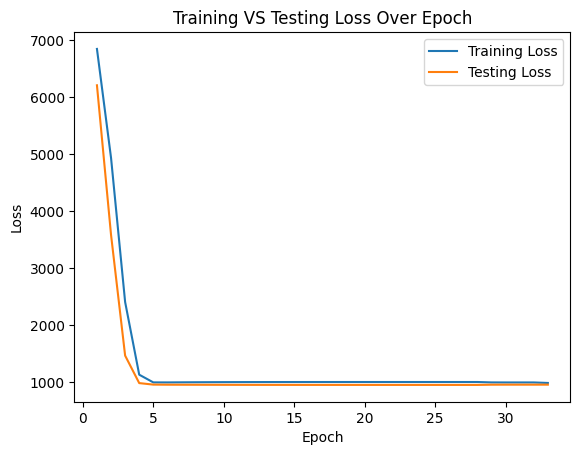

In [67]:
plt.plot(range(1, len(training_losses) + 1), training_losses, label = "Training Loss")
plt.plot(range(1, len(training_losses) + 1), testing_losses, label = "Testing Loss")
plt.legend()
plt.title("Training VS Testing Loss Over Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

This cell defines an Optuna objective function for hyperparameter tuning of the LSTM model. It suggests values for learning rate, hidden layer size, and optimizer type, then builds and trains an LSTM with those parameters for 15 epochs. During training, it computes the loss on each batch, backpropagates, and updates the model weights. After each epoch, it evaluates the model on the validation set to calculate RMSE, reports it to Optuna, and checks if the trial should be pruned early to save time. The final RMSE is returned as the objective value.

In [68]:
def objective(trial):
    lr = trial.suggest_float('lr', 1e-5, 1e-3)
    fc1_size = trial.suggest_int('fc1_size', 64, 256)
    optimizer = trial.suggest_categorical('optimizer', ['Adam', 'RMSprop', 'SGD'])

    model = LSTM(input_size = 25, hidden_size = fc1_size, num_layers = 2).to(device)

    if optimizer == 'Adam':
        optimizer = torch.optim.Adam(params = model.parameters(), lr = lr, weight_decay = 1e-4)
    elif optimizer == 'SGD':
        lr_sgd = trial.suggest_float('lr_sgd', 1e-6, 5e-4)
        optimizer = torch.optim.SGD(params = model.parameters(), lr = lr_sgd, momentum = 0.9,weight_decay = 1e-4)
    else:
        optimizer = torch.optim.RMSprop(params = model.parameters(), lr = lr, weight_decay = 1e-4, alpha = 0.99)

    loss_function = nn.MSELoss()

    for epoch in range(15):
        model.train()
        for set_x, set_y in train_loader:
            set_x, set_y = set_x.to(device), set_y.to(device)
            optimizer.zero_grad()
            outputs = model(set_x)
            loss = loss_function(outputs, set_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        
        val_loss = 0
        model.eval()
        with torch.no_grad():
            for set_x, set_y in validation_loader:
                set_x, set_y = set_x.to(device), set_y.to(device)
                outputs = model(set_x)
                loss = loss_function(outputs, set_y)
                val_loss += loss.item()
        val_error = val_loss/len(validation_loader)
        rmse = np.sqrt(val_error)
        trial.report(rmse, step = epoch)
        if trial.should_prune():
            raise TrialPruned()
    return rmse

In [69]:
study = optuna.create_study(direction = 'minimize')
study.optimize(objective, n_trials = 50)
print("Best Parameters : ")
print(study.best_params)
print("Best Value : ")
print(study.best_value)

[I 2026-01-25 15:58:51,491] A new study created in memory with name: no-name-163050ec-3183-4ff4-8b39-75736ea8e12f
[I 2026-01-25 15:59:12,317] Trial 0 finished with value: 7102.4083678850675 and parameters: {'lr': 0.0008517516457033084, 'fc1_size': 180, 'optimizer': 'SGD', 'lr_sgd': 2.9177795148609125e-05}. Best is trial 0 with value: 7102.4083678850675.
[I 2026-01-25 15:59:32,577] Trial 1 finished with value: 1291.9495519196614 and parameters: {'lr': 0.0004423688393215773, 'fc1_size': 159, 'optimizer': 'Adam'}. Best is trial 1 with value: 1291.9495519196614.
[I 2026-01-25 16:00:08,107] Trial 2 finished with value: 1290.9486927330258 and parameters: {'lr': 0.00043856451863137825, 'fc1_size': 249, 'optimizer': 'Adam'}. Best is trial 2 with value: 1290.9486927330258.
[I 2026-01-25 16:00:42,233] Trial 3 finished with value: 2037.74188435659 and parameters: {'lr': 0.00017328247903113016, 'fc1_size': 246, 'optimizer': 'RMSprop'}. Best is trial 2 with value: 1290.9486927330258.
[I 2026-01-25 

Best Parameters : 
{'lr': 0.0009682851332870842, 'fc1_size': 144, 'optimizer': 'RMSprop'}
Best Value : 
619.6735242826298


In [70]:
optuna.visualization.plot_optimization_history(study).show()

In [71]:
optuna.visualization.plot_param_importances(study).show()

This cell prepares the data for a second round of training and testing. It combines specific parts of the dataset to create updated training and testing sets, separates the features (X) and target (y), and converts them into PyTorch tensors. Then, it wraps these tensors into TensorDataset objects and creates DataLoaders with a batch size of 64 to feed data efficiently into the model during training and evaluation.

In [72]:
training_data = lstm_load_data.iloc[:28000, :]
testing_data = lstm_load_data.iloc[28000:, : ]
training_y = torch.tensor(training_data[['target_load_1h']].values, dtype = torch.float32)
training_x = torch.tensor(training_data.drop(columns = ['target_load_1h'], axis = 1).values, dtype = torch.float32) 
testing_y = torch.tensor(testing_data[['target_load_1h']].values, dtype = torch.float32)
testing_x = torch.tensor(testing_data.drop(columns = ['target_load_1h'], axis = 1).values, dtype = torch.float32)
train_set = torch.utils.data.TensorDataset(training_x, training_y)
test_set = torch.utils.data.TensorDataset(testing_x, testing_y)
train_loader2 = torch.utils.data.DataLoader(dataset = train_set, batch_size = 64, shuffle = False)
test_loader2 = torch.utils.data.DataLoader(dataset = test_set, shuffle = False, batch_size = 64)

This cell trains the final LSTM model using the best hyperparameters found from the Optuna study. It sets up the model, optimizer, and MSE loss function, then runs training for 100 epochs. In each epoch, it updates the model weights using the training data, calculates the average training loss, and evaluates the model on the test data to compute the test loss. Both training and testing RMSE values are recorded and printed after every epoch to monitor the model’s performance.

In [73]:
lr = study.best_params['lr']
hidden_size = study.best_params['fc1_size']
optimizer = study.best_params['optimizer']
load_model = LSTM(input_size = 25, hidden_size = hidden_size,  num_layers = 2).to(device)
if optimizer == 'Adam':
    optimizer = torch.optim.Adam(params = load_model.parameters(), lr = lr, weight_decay = 1e-4)
elif optimizer == 'SGD':
    optimizer = torch.optim.SGD(params = load_model.parameters(), lr = lr, momentum = 0.9, weight_decay = 1e-4)
else:
    optimizer = torch.optim.RMSprop(params = load_model.parameters(), lr = lr, weight_decay = 1e-4, alpha = 0.99)

loss_function = nn.MSELoss()
train_losses = []
test_losses = []
patience = 5
min_delta = 1e-4
best_test_loss = float("inf")
counter = 0

for epoch in range(100):
    load_model.train()
    running_training_loss = 0
    running_testing_loss = 0
    for x_part, y_part in train_loader2:
        x_part, y_part = x_part.to(device), y_part.to(device)
        optimizer.zero_grad()
        outputs = load_model(x_part)
        loss = loss_function(outputs, y_part)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(load_model.parameters(), 1.0)
        optimizer.step()
        running_training_loss += loss.item()
    error = running_training_loss/len(train_loader2)
    train_losses.append(np.sqrt(error))

    load_model.eval()
    with torch.no_grad():
        for x_part, y_part in test_loader2:
            x_part, y_part = x_part.to(device), y_part.to(device)
            outputs = load_model(x_part)
            loss = loss_function(outputs, y_part)
            running_testing_loss += loss.item()
        final_loss = running_testing_loss/len(test_loader2)
        test_losses.append(np.sqrt(final_loss))
    print(f"Epoch : {epoch + 1} ---- Training Loss : {np.sqrt(error):.4f} ---- Testing Loss : {np.sqrt(final_loss):.4f}")
    if best_test_loss - final_loss > min_delta:
        best_test_loss = final_loss
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print(f"Early stopping at epoch {epoch + 1}")
        break

Epoch : 1 ---- Training Loss : 6715.3093 ---- Testing Loss : 6142.3908
Epoch : 2 ---- Training Loss : 4938.2321 ---- Testing Loss : 3587.3441
Epoch : 3 ---- Training Loss : 2155.9898 ---- Testing Loss : 1013.2257
Epoch : 4 ---- Training Loss : 759.7488 ---- Testing Loss : 794.3891
Epoch : 5 ---- Training Loss : 570.4331 ---- Testing Loss : 759.2676
Epoch : 6 ---- Training Loss : 522.2198 ---- Testing Loss : 744.5658
Epoch : 7 ---- Training Loss : 500.0086 ---- Testing Loss : 711.9083
Epoch : 8 ---- Training Loss : 478.2717 ---- Testing Loss : 634.8336
Epoch : 9 ---- Training Loss : 460.1068 ---- Testing Loss : 644.7154
Epoch : 10 ---- Training Loss : 443.7408 ---- Testing Loss : 643.4357
Epoch : 11 ---- Training Loss : 431.0264 ---- Testing Loss : 642.0389
Epoch : 12 ---- Training Loss : 420.1256 ---- Testing Loss : 618.6446
Epoch : 13 ---- Training Loss : 417.3814 ---- Testing Loss : 608.8803
Epoch : 14 ---- Training Loss : 399.7511 ---- Testing Loss : 618.4525
Epoch : 15 ---- Trainin

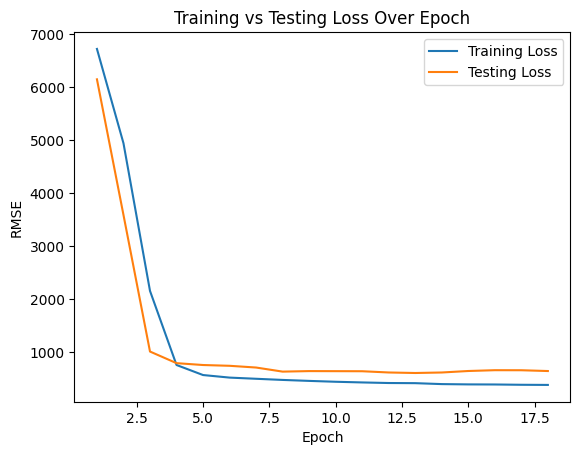

In [74]:
plt.plot(range(1, len(train_losses) + 1), train_losses, label="Training Loss")
plt.plot(range(1, len(train_losses) + 1), test_losses, label="Testing Loss")
plt.xlabel("Epoch") 
plt.ylabel("RMSE")
plt.title("Training vs Testing Loss Over Epoch")
plt.legend()
plt.show()

In [75]:
def predict_full(model, data_loader):
    model.eval()
    all_outputs = []
    with torch.no_grad():
        for x_part, _ in data_loader:
            x_part = x_part.to(device)
            out = model(x_part)
            all_outputs.append(out.cpu().numpy())
    return np.concatenate(all_outputs, axis=0)

In [76]:
load  = predict_full(load_model, test_loader2)

This cell loads the data for the prediction of Solar and Wind energy

In [77]:
data3 = np.load(r'C:\Users\kaifm\Downloads\weather_stack_mar2023_aug2025.npy')
data3 = np.nan_to_num(data3, nan = 0.0)

This cell scales the data3 array for each channel separately using Min-Max normalization. First, it rearranges the array dimensions to (samples, channels, height, width). Then, for each channel, it flattens the spatial dimensions, applies MinMaxScaler to scale values between 0 and 1, and reshapes the scaled data back to its original height and width. This ensures all channels are normalized consistently for model input.

In [78]:
data3 = np.transpose(data3, (0, 3, 1, 2))
N, C, H, W = data3.shape
data_scaled = np.zeros_like(data3)
for c in range(C):
    scaler = MinMaxScaler()
    flat = data3[:, c, :, :].reshape(N, -1)
    flat_scaled = scaler.fit_transform(flat)
    data_scaled[:, c, :, :] = flat.reshape(N, H, W)

In [79]:
data_scaled.shape

(30673, 6, 21, 48)

This cell removes channel 1 as it is not important for the prediction in the case of solar_target_1h

In [80]:
keep_channels = [0, 2, 3, 4, 5]
solar_data = data_scaled[:, keep_channels, :, :]

In [81]:
solar_data.shape

(30673, 5, 21, 48)

This cell prepares the input sequences and targets for a time series prediction task. It uses a sliding window of length 12 (seq_length) over solar_data to create sequential input samples (X) and takes the value of target_solar_1h right after each sequence as the target (y). Finally, it converts the lists to NumPy arrays and prints their shapes to confirm the data dimensions.

In [82]:
seq_length = 12
x_list = []
y_list = []
for i in range(len(data2) - seq_length):
    seq = solar_data[i:i+seq_length]
    target = data2['target_solar_1h'].iloc[i+seq_length]
    x_list.append(seq)
    y_list.append(target)

X = np.array(x_list, dtype = np.float32)
y = np.array(y_list, dtype = np.float32).reshape(-1, 1)

print("Shape of X : ", X.shape)
print("Shape of y", y.shape)

Shape of X :  (30660, 12, 5, 21, 48)
Shape of y (30660, 1)


This cell splits the sequence data into training, validation, and testing sets using specific index ranges. It adjusts the indices to account for the sequence length so that each input sequence aligns correctly with its target. The validation and test sets are created by concatenating two separate segments to handle gaps in the data. Finally, it prints the shapes of X_train, X_val, and X_test to confirm the splits.

In [83]:
seq_length = 12

train_idx_end = 18000
val_idx_start = 18000
val_idx_end   = 28000
test_idx_start = 28000

# Train
X_train = X[:train_idx_end - seq_length]       
y_train = y[:train_idx_end - seq_length]

# Validation
X_val = X[val_idx_start - seq_length:val_idx_end - seq_length]           
y_val = y[val_idx_start:val_idx_end]

# Test
X_test = X[test_idx_start - seq_length: -seq_length]                  
y_test = y[test_idx_start:]

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)


X_train shape: (17988, 12, 5, 21, 48)
X_val shape: (10000, 12, 5, 21, 48)
X_test shape: (2660, 12, 5, 21, 48)


This cell prepares the sequence data for PyTorch training. It converts the NumPy arrays for inputs and targets into PyTorch tensors, wraps them into TensorDataset objects to pair each input with its target, and then creates DataLoaders with a batch size of 64. These DataLoaders allow efficient batch-wise access to the training, validation, and test data during model training and evaluation.

In [84]:
batch_size = 64

# Convert to torch tensors
X_train_tensor = torch.tensor(X_train)
y_train_tensor = torch.tensor(y_train)
X_val_tensor = torch.tensor(X_val)
y_val_tensor = torch.tensor(y_val)
X_test_tensor = torch.tensor(X_test)
y_test_tensor = torch.tensor(y_test)

# Create datasets
train_set = TensorDataset(X_train_tensor, y_train_tensor)
val_set = TensorDataset(X_val_tensor, y_val_tensor)
test_set = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=False)
validation_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

print("DataLoaders ready!")


DataLoaders ready!


C:\Users\kaifm\AppData\Local\Temp\ipykernel_26012\1627474299.py:17: UserWarning:

'data.DataLoader' is deprecated, use 'loader.DataLoader' instead

C:\Users\kaifm\AppData\Local\Temp\ipykernel_26012\1627474299.py:18: UserWarning:

'data.DataLoader' is deprecated, use 'loader.DataLoader' instead

C:\Users\kaifm\AppData\Local\Temp\ipykernel_26012\1627474299.py:19: UserWarning:

'data.DataLoader' is deprecated, use 'loader.DataLoader' instead



This cell defines a hybrid CNN-LSTM model for spatiotemporal data. The model first applies two 2D convolutional layers with ReLU, max pooling, and dropout to extract spatial features from each frame. The resulting feature maps are flattened and passed through a fully connected layer to reduce dimensionality. These processed sequences are then fed into an LSTM to capture temporal dependencies, and the final hidden state is passed through a linear layer to produce a single prediction. This architecture combines spatial feature extraction (CNN) with sequence modeling (LSTM).

In [85]:
class CNN_LSTM(nn.Module):
    def __init__(self, in_features, cnn_out_size, hidden_size, H, W, dropout_size = 0.20):
        super(CNN_LSTM, self).__init__()
        self.conv1 = nn.Conv2d(in_channels = in_features, out_channels = 16, kernel_size = (3, 3), padding = 1)
        self.conv2 = nn.Conv2d(in_channels = 16, out_channels = 32, kernel_size = (3, 3), padding = 1)
        self.dropout = nn.Dropout2d(dropout_size)
        self.maxpool = nn.MaxPool2d(kernel_size = (2, 2), stride = 2)
        flattened_size = 32 * (H // 4) * (W // 4)
        self.fc1 = nn.Linear(in_features = flattened_size, out_features = cnn_out_size)
        self.lstm = nn.LSTM(input_size = cnn_out_size, hidden_size = hidden_size, num_layers = 2, batch_first = True)
        self.fc2 = nn.Linear(in_features = hidden_size, out_features = 1)
        self.relu = nn.ReLU()


    def forward(self, x):
        batch_size, seq_length, C, H, W = x.shape
        x = x.view(batch_size*seq_length, C, H, W)
        x = self.dropout(self.maxpool(self.relu(self.conv1(x))))
        x = self.dropout(self.maxpool(self.relu(self.conv2(x))))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = x.view(batch_size, seq_length, -1)
        out, (hn, cn) = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc2(out)
        return out

In [86]:
model = CNN_LSTM(in_features = 5, cnn_out_size = 128, hidden_size = 256, H = 21, W = 48).to(device)
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(params = model.parameters(), lr = 1e-4)
scheduler = ReduceLROnPlateau(optimizer = optimizer, mode = 'min', patience = 3, factor = 0.5)

This cell trains the CNN-LSTM model for 100 epochs while tracking performance. In each epoch, it sets the model to training mode, feeds batches from the training data, computes the loss, backpropagates, and updates the model weights. It calculates the average training RMSE and stores it. Then, in evaluation mode, it computes the RMSE on the test data without updating weights, updates the learning rate scheduler, and prints the training and testing RMSE for each epoch to monitor the model’s progress.

In [87]:
training_losses = []
testing_losses = []
patience = 5
min_delta = 1e-4
best_test_loss = float("inf")
counter = 0

for epoch in range(100):
    model.train()
    running_training_loss = 0
    running_testing_loss = 0
    for set_x, set_y in train_loader:
        set_x, set_y = set_x.to(device), set_y.to(device)
        optimizer.zero_grad()
        outputs = model(set_x)
        loss = loss_function(outputs, set_y)
        loss.backward()
        optimizer.step()
        running_training_loss += loss.item()
    train_error = running_training_loss/len(train_loader)
    training_losses.append(np.sqrt(train_error))

    model.eval()
    with torch.no_grad():
        for set_x, set_y in test_loader:
            set_x, set_y = set_x.to(device), set_y.to(device)
            outputs = model(set_x)
            loss = loss_function(outputs, set_y)
            running_testing_loss += loss.item()
        final_loss = running_testing_loss/len(test_loader)
        testing_losses.append(np.sqrt(final_loss))
        scheduler.step(final_loss)
    print(f"Epoch : {epoch + 1} ---- Training Loss : {np.sqrt(train_error)} ---- Testing Error : {np.sqrt(final_loss)}")
    if best_test_loss - final_loss > min_delta:
        best_test_loss = final_loss
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print(f"Early stopping at epoch {epoch + 1}")
        break

Epoch : 1 ---- Training Loss : 903.281940054615 ---- Testing Error : 2348.443314831378
Epoch : 2 ---- Training Loss : 898.7524437473077 ---- Testing Error : 2344.285303313855
Epoch : 3 ---- Training Loss : 895.4704028527817 ---- Testing Error : 2340.346256687347
Epoch : 4 ---- Training Loss : 892.3215826429125 ---- Testing Error : 2336.5015438226687
Epoch : 5 ---- Training Loss : 889.2570661805756 ---- Testing Error : 2332.721224133696
Epoch : 6 ---- Training Loss : 886.2600593789626 ---- Testing Error : 2328.991696298759
Epoch : 7 ---- Training Loss : 883.3222180526775 ---- Testing Error : 2325.3055073217697
Epoch : 8 ---- Training Loss : 880.4386074797948 ---- Testing Error : 2321.657889131529
Epoch : 9 ---- Training Loss : 877.6060395262888 ---- Testing Error : 2318.0458557340307
Epoch : 10 ---- Training Loss : 874.8223002875637 ---- Testing Error : 2314.4672578155
Epoch : 11 ---- Training Loss : 872.0857456723004 ---- Testing Error : 2310.920378128078
Epoch : 12 ---- Training Loss 

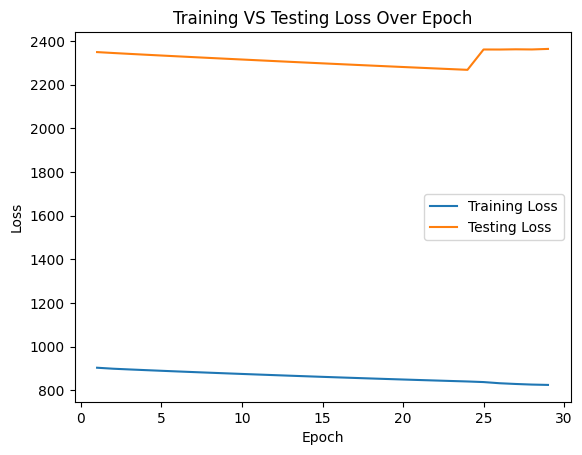

In [88]:
plt.plot(range(1, len(training_losses) + 1), training_losses, label = "Training Loss")
plt.plot(range(1, len(training_losses) + 1), testing_losses, label = "Testing Loss")
plt.legend()
plt.title("Training VS Testing Loss Over Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

This cell defines an Optuna objective function to tune the hyperparameters of the CNN-LSTM model. It suggests values for learning rate, CNN and LSTM layer sizes, dropout, and optimizer type, then builds and trains the model for 5 epochs. During training, it computes the loss on each batch, backpropagates, and updates the model weights. After each epoch, it evaluates the model on the validation set to calculate RMSE, reports it to Optuna, and allows early pruning of underperforming trials. The final RMSE is returned as the trial’s objective value.

In [89]:
def objective(trial):
    lr = trial.suggest_float('lr', 1e-5, 1e-3)
    fc1_size = trial.suggest_int('fc1_size', 64, 256)
    fc2_size = trial.suggest_int('fc2_size', 64, 256)
    dropout = trial.suggest_float('dropout', 0.20, 0.50)
    optimizer = trial.suggest_categorical('optimizer', ['Adam', 'RMSprop', 'SGD'])

    model = CNN_LSTM(in_features = 5, cnn_out_size = fc1_size,hidden_size = fc2_size, dropout_size = dropout, H = 21, W = 48).to(device)

    if optimizer == 'Adam':
        optimizer = torch.optim.Adam(params = model.parameters(), lr = lr, weight_decay = 1e-4)
    elif optimizer == 'SGD':
        lr_sgd = trial.suggest_float('lr_sgd', 1e-6, 5e-4)
        optimizer = torch.optim.SGD(params = model.parameters(), lr = lr_sgd, momentum = 0.9,weight_decay = 1e-4)
    else:
        optimizer = torch.optim.RMSprop(params = model.parameters(), lr = lr, weight_decay = 1e-4, alpha = 0.99)

    loss_function = nn.MSELoss()

    for epoch in range(5):
        model.train()
        for set_x, set_y in train_loader:
            set_x, set_y = set_x.to(device), set_y.to(device)
            optimizer.zero_grad()
            outputs = model(set_x)
            loss = loss_function(outputs, set_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        
        val_loss = 0
        model.eval()
        with torch.no_grad():
            for set_x, set_y in validation_loader:
                set_x, set_y = set_x.to(device), set_y.to(device)
                outputs = model(set_x)
                loss = loss_function(outputs, set_y)
                val_loss += loss.item()
        val_error = val_loss/len(validation_loader)
        rmse = np.sqrt(val_error)
        trial.report(rmse, step = epoch)
        if trial.should_prune():
            raise TrialPruned()
    return rmse

In [90]:
study = optuna.create_study(direction = 'minimize')
study.optimize(objective, n_trials = 15)
print("Best Params : ")
print(study.best_params)
print("Best Value")
print(study. best_value)

[I 2026-01-25 16:09:59,991] A new study created in memory with name: no-name-25b04f90-db6d-40b5-aaab-1c8655a61dbc
[I 2026-01-25 16:10:23,953] Trial 0 finished with value: 1362.738970403178 and parameters: {'lr': 0.00041353140561110717, 'fc1_size': 192, 'fc2_size': 185, 'dropout': 0.3596724251617448, 'optimizer': 'RMSprop'}. Best is trial 0 with value: 1362.738970403178.
[I 2026-01-25 16:10:46,547] Trial 1 finished with value: 1426.187244623828 and parameters: {'lr': 0.0009883128096631675, 'fc1_size': 124, 'fc2_size': 201, 'dropout': 0.33677278655138065, 'optimizer': 'RMSprop'}. Best is trial 0 with value: 1362.738970403178.
[I 2026-01-25 16:11:07,910] Trial 2 finished with value: 1382.4032927649164 and parameters: {'lr': 0.000533107014561698, 'fc1_size': 204, 'fc2_size': 88, 'dropout': 0.33448996507187634, 'optimizer': 'Adam'}. Best is trial 0 with value: 1362.738970403178.
[I 2026-01-25 16:11:29,040] Trial 3 finished with value: 1393.1741955234643 and parameters: {'lr': 0.000410698040

Best Params : 
{'lr': 0.0008894264242160337, 'fc1_size': 100, 'fc2_size': 227, 'dropout': 0.2988807941062583, 'optimizer': 'Adam'}
Best Value
1330.761627945636


In [91]:
optuna.visualization.plot_optimization_history(study).show()

In [92]:
optuna.visualization.plot_param_importances(study).show()

This cell prepares the solar time series data for training and testing an LSTM model. It first creates sequences of length 12 (seq_length) as inputs and the next hour’s solar value as the target. Then, it splits the sequences into training and testing sets based on specific index ranges, handling multiple non-contiguous segments. After that, it converts the arrays to PyTorch tensors, wraps them in TensorDatasets, and creates DataLoaders with a batch size of 64 for efficient batch-wise access during model training and evaluation.

In [93]:
seq_length = 12

# Create sequences
x_list = []
y_list = []
for i in range(len(data2) - seq_length):
    seq = solar_data[i:i+seq_length]
    target = data2['target_solar_1h'].iloc[i+seq_length]
    x_list.append(seq)
    y_list.append(target)

X = np.array(x_list, dtype=np.float32)
y = np.array(y_list, dtype=np.float32).reshape(-1, 1)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)


train_end = 28000 - seq_length  # drop first seq_length to match sequences

X_train = X[:train_end]
y_train = y[:train_end]

# Test: rest of the rows
X_test = X[train_end:]
y_test = y[train_end:]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
# Convert to torch tensors
batch_size = 64
X_train_tensor = torch.tensor(X_train)
y_train_tensor = torch.tensor(y_train)
X_test_tensor = torch.tensor(X_test)
y_test_tensor = torch.tensor(y_test)

# Create datasets
train_set = TensorDataset(X_train_tensor, y_train_tensor)
test_set = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

print("DataLoaders ready!")

Shape of X: (30660, 12, 5, 21, 48)
Shape of y: (30660, 1)
X_train shape: (27988, 12, 5, 21, 48)
X_test shape: (2672, 12, 5, 21, 48)


C:\Users\kaifm\AppData\Local\Temp\ipykernel_26012\4270861838.py:42: UserWarning:

'data.DataLoader' is deprecated, use 'loader.DataLoader' instead



DataLoaders ready!


C:\Users\kaifm\AppData\Local\Temp\ipykernel_26012\4270861838.py:43: UserWarning:

'data.DataLoader' is deprecated, use 'loader.DataLoader' instead



This cell trains the final CNN-LSTM model using the best hyperparameters found from the Optuna study. It sets up the model, selects the optimizer, and defines MSE loss. Over 30 epochs, it updates the model weights using the training data, calculates the average training RMSE, and evaluates the model on the test data to get the testing RMSE. Both training and testing losses are recorded and printed each epoch to monitor the model’s performance.

In [94]:
lr = study.best_params['lr']
cnn_out_size = study.best_params['fc1_size']
hidden_size = study.best_params['fc2_size']
optimizer = study.best_params['optimizer']
dropout = study.best_params['dropout']
solar_model = CNN_LSTM(in_features = 5, cnn_out_size = cnn_out_size,hidden_size = hidden_size, dropout_size = dropout, H = 21, W = 48).to(device)
if optimizer == 'Adam':
    optimizer = torch.optim.Adam(params = solar_model.parameters(), lr = lr, weight_decay = 1e-4)
elif optimizer == 'SGD':
    optimizer = torch.optim.SGD(params = solar_model.parameters(), lr = lr, momentum = 0.9, weight_decay = 1e-4)
else:
    optimizer = torch.optim.RMSprop(params = solar_model.parameters(), lr = lr, weight_decay = 1e-4, alpha = 0.99)

loss_function = nn.MSELoss()
train_losses = []
test_losses = []
patience = 5
min_delta = 1e-4
best_test_loss = float("inf")
counter = 0

for epoch in range(30):
    solar_model.train()
    running_training_loss = 0
    running_testing_loss = 0
    for x_part, y_part in train_loader:
        x_part, y_part = x_part.to(device), y_part.to(device)
        optimizer.zero_grad()
        outputs = solar_model(x_part)
        loss = loss_function(outputs, y_part)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(solar_model.parameters(), 1.0)
        optimizer.step()
        running_training_loss += loss.item()
    error = running_training_loss/len(train_loader2)
    train_losses.append(np.sqrt(error))

    solar_model.eval()
    with torch.no_grad():
        for x_part, y_part in test_loader:
            x_part, y_part = x_part.to(device), y_part.to(device)
            outputs = solar_model(x_part)
            loss = loss_function(outputs, y_part)
            running_testing_loss += loss.item()
        final_loss = running_testing_loss/len(test_loader2)
        test_losses.append(np.sqrt(final_loss))
    print(f"Epoch : {epoch + 1} ---- Training Loss : {np.sqrt(error):.4f} ---- Testing Loss : {np.sqrt(final_loss):.4f}")
    if best_test_loss - final_loss > min_delta:
        best_test_loss = final_loss
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print(f"Early stopping at epoch {epoch + 1}")
        break

Epoch : 1 ---- Training Loss : 1096.9412 ---- Testing Loss : 2295.4059
Epoch : 2 ---- Training Loss : 1069.7029 ---- Testing Loss : 2263.8628
Epoch : 3 ---- Training Loss : 1045.2504 ---- Testing Loss : 2235.6333
Epoch : 4 ---- Training Loss : 1026.9430 ---- Testing Loss : 2207.3620
Epoch : 5 ---- Training Loss : 994.4569 ---- Testing Loss : 2176.9788
Epoch : 6 ---- Training Loss : 978.1183 ---- Testing Loss : 2153.3247
Epoch : 7 ---- Training Loss : 957.2703 ---- Testing Loss : 2128.2559
Epoch : 8 ---- Training Loss : 929.6939 ---- Testing Loss : 2102.3007
Epoch : 9 ---- Training Loss : 912.6895 ---- Testing Loss : 2080.8687
Epoch : 10 ---- Training Loss : 963.2652 ---- Testing Loss : 2091.7953
Epoch : 11 ---- Training Loss : 907.8068 ---- Testing Loss : 2066.6646
Epoch : 12 ---- Training Loss : 894.3074 ---- Testing Loss : 2044.9967
Epoch : 13 ---- Training Loss : 906.3315 ---- Testing Loss : 2100.4084
Epoch : 14 ---- Training Loss : 894.1184 ---- Testing Loss : 1998.1716
Epoch : 15 

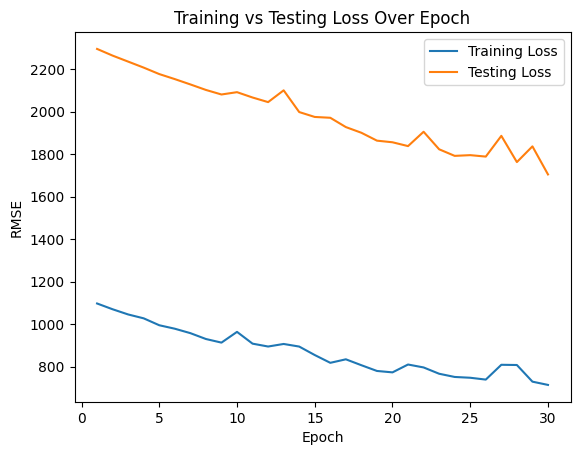

In [95]:
plt.plot(range(1, len(train_losses) + 1), train_losses, label="Training Loss")
plt.plot(range(1, len(train_losses) + 1), test_losses, label="Testing Loss")
plt.xlabel("Epoch") 
plt.ylabel("RMSE")
plt.title("Training vs Testing Loss Over Epoch")
plt.legend()
plt.show()

In [96]:
solar = predict_full(solar_model, test_loader)

CNN-LSTM Wind

This code selects only channel 0 and 1 for the prediction of target_wind_1h

In [97]:
keep_channels = [0, 1]
wind_data = data_scaled[:, keep_channels, :, :]


In [98]:
wind_data.shape

(30673, 2, 21, 48)

This cell prepares the wind time series data for modeling. It creates sequences of length 12 (seq_length) from wind_data as input features and uses the next hour’s wind value (target_wind_1h) as the target. The sequences and targets are stored in NumPy arrays X and y, which are then reshaped for PyTorch compatibility. Finally, it prints the shapes of X and y to verify the data preparation.

In [99]:
seq_length = 12
x_list = []
y_list = []
for i in range(len(data2) - seq_length):
    seq = wind_data[i:i+seq_length]
    target = data2['target_wind_1h'].iloc[i+seq_length]
    x_list.append(seq)
    y_list.append(target)

X = np.array(x_list, dtype = np.float32)
y = np.array(y_list, dtype = np.float32).reshape(-1, 1)

print("Shape of X : ", X.shape)
print("Shape of y", y.shape)

Shape of X :  (30660, 12, 2, 21, 48)
Shape of y (30660, 1)


This cell splits the wind sequences into training, validation, and testing sets based on predefined index ranges. It carefully adjusts the start and end indices to account for the sequence length and concatenates non-contiguous segments for validation and testing. The final NumPy arrays X_train, X_val, X_test (and their corresponding targets) are printed to confirm the shapes of each dataset.

In [100]:
seq_length = 12
# Step 2: Define aligned train/val/test indices
train_end_idx = 18000 - seq_length  # train until 18000
val_end_idx   = 28000 - seq_length  # validation until 28000
test_start_idx = val_end_idx         # test starts from end of validation

# Step 3: Split the data
X_train = X[:train_end_idx]
y_train = y[:train_end_idx]

X_val = X[train_end_idx:val_end_idx]
y_val = y[train_end_idx:val_end_idx]

X_test = X[test_start_idx:]
y_test = y[test_start_idx:]

print("X_train:", X_train.shape, "X_val:", X_val.shape, "X_test:", X_test.shape)

X_train: (17988, 12, 2, 21, 48) X_val: (10000, 12, 2, 21, 48) X_test: (2672, 12, 2, 21, 48)


This cell converts the wind sequence arrays and their targets into PyTorch tensors, then wraps them into TensorDataset objects for training, validation, and testing. After that, DataLoaders are created to efficiently feed batches of size 64 to the model during training and evaluation. Finally, it prints a confirmation that the data loaders are ready for use.

In [101]:
batch_size = 64

# Convert to torch tensors
X_train_tensor = torch.tensor(X_train)
y_train_tensor = torch.tensor(y_train)
X_val_tensor = torch.tensor(X_val)
y_val_tensor = torch.tensor(y_val)
X_test_tensor = torch.tensor(X_test)
y_test_tensor = torch.tensor(y_test)

# Create datasets
train_set = TensorDataset(X_train_tensor, y_train_tensor)
val_set = TensorDataset(X_val_tensor, y_val_tensor)
test_set = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=False)
validation_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

print("DataLoaders ready!")

C:\Users\kaifm\AppData\Local\Temp\ipykernel_26012\2169819245.py:17: UserWarning:

'data.DataLoader' is deprecated, use 'loader.DataLoader' instead



DataLoaders ready!


C:\Users\kaifm\AppData\Local\Temp\ipykernel_26012\2169819245.py:18: UserWarning:

'data.DataLoader' is deprecated, use 'loader.DataLoader' instead

C:\Users\kaifm\AppData\Local\Temp\ipykernel_26012\2169819245.py:19: UserWarning:

'data.DataLoader' is deprecated, use 'loader.DataLoader' instead



In [102]:
model = CNN_LSTM(in_features = 2, cnn_out_size = 128, hidden_size = 256, dropout_size = 0.20, H = 21, W = 48).to(device)
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(params = model.parameters(), lr = 1e-4)
scheduler = ReduceLROnPlateau(optimizer = optimizer, mode = 'min', patience = 3, factor = 0.5)

This code trains model for 100 epochs while tracking performance. For each epoch, it loops over the training data, computes predictions, calculates the loss using MSE, backpropagates, and updates the model parameters. The average training loss for the epoch is recorded as RMSE. Then, in evaluation mode, it calculates the RMSE on the test set without updating the model. The learning rate scheduler is updated based on the test error, and both training and testing RMSE are printed at the end of each epoch.

In [103]:
training_losses = []
testing_losses = []
patience = 5
min_delta = 1e-4
best_test_loss = float("inf")
counter = 0

for epoch in range(100):
    model.train()
    running_training_loss = 0
    running_testing_loss = 0
    for set_x, set_y in train_loader:
        set_x, set_y = set_x.to(device), set_y.to(device)
        optimizer.zero_grad()
        outputs = model(set_x)
        loss = loss_function(outputs, set_y)
        loss.backward()
        optimizer.step()
        running_training_loss += loss.item()
    train_error = running_training_loss/len(train_loader)
    training_losses.append(np.sqrt(train_error))

    model.eval()
    with torch.no_grad():
        for set_x, set_y in test_loader:
            set_x, set_y = set_x.to(device), set_y.to(device)
            outputs = model(set_x)
            loss = loss_function(outputs, set_y)
            running_testing_loss += loss.item()
        final_loss = running_testing_loss/len(test_loader)
        testing_losses.append(np.sqrt(final_loss))
        scheduler.step(final_loss)
    print(f"Epoch : {epoch + 1} ---- Training Loss : {np.sqrt(train_error)} ---- Testing Error : {np.sqrt(final_loss)}")
    if best_test_loss - final_loss > min_delta:
        best_test_loss = final_loss
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print(f"Early stopping at epoch {epoch + 1}")
        break

Epoch : 1 ---- Training Loss : 17.614179551532946 ---- Testing Error : 11.637287979961346
Epoch : 2 ---- Training Loss : 16.041674270410237 ---- Testing Error : 11.830549725030108
Epoch : 3 ---- Training Loss : 15.777004997757677 ---- Testing Error : 12.126550814031933
Epoch : 4 ---- Training Loss : 15.714385074344573 ---- Testing Error : 12.342675642519989
Epoch : 5 ---- Training Loss : 15.705643874647034 ---- Testing Error : 12.475473840252722
Epoch : 6 ---- Training Loss : 15.692912183365502 ---- Testing Error : 12.486305117171248
Early stopping at epoch 6


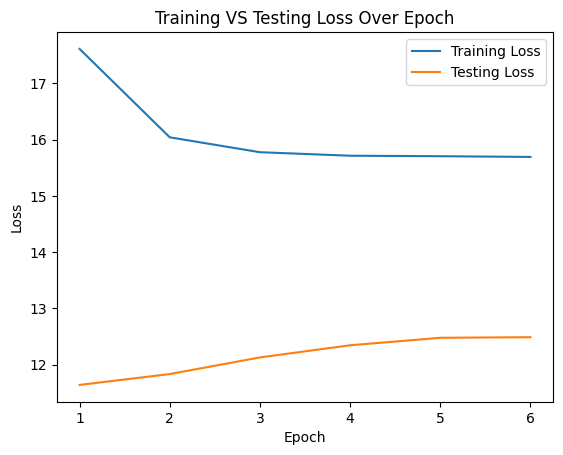

In [104]:
plt.plot(range(1, len(training_losses) + 1), training_losses, label = "Training Loss")
plt.plot(range(1, len(training_losses) + 1), testing_losses, label = "Testing Loss")
plt.legend()
plt.title("Training VS Testing Loss Over Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

This objective function is for Optuna tuning. It suggests hyperparameters, builds a CNN_LSTM model, and sets the optimizer. The model trains for 5 epochs using MSE loss, with gradient clipping. After each epoch, it evaluates RMSE on the validation set, reports it, and may prune poor trials. The function returns the validation RMSE for Optuna to optimize.

In [105]:
def objective(trial):
    lr = trial.suggest_float('lr', 1e-5, 1e-3)
    fc1_size = trial.suggest_int('fc1_size', 64, 256)
    fc2_size = trial.suggest_int('fc2_size', 64, 256)
    dropout = trial.suggest_float('dropout', 0.20, 0.50)
    optimizer = trial.suggest_categorical('optimizer', ['Adam', 'RMSprop', 'SGD'])

    model = CNN_LSTM(in_features = 2, cnn_out_size = fc1_size,hidden_size = fc2_size, dropout_size = dropout, H = 21, W = 48).to(device)

    if optimizer == 'Adam':
        optimizer = torch.optim.Adam(params = model.parameters(), lr = lr, weight_decay = 1e-4)
    elif optimizer == 'SGD':
        lr_sgd = trial.suggest_float('lr_sgd', 1e-6, 5e-4)
        optimizer = torch.optim.SGD(params = model.parameters(), lr = lr_sgd, momentum = 0.9,weight_decay = 1e-4)
    else:
        optimizer = torch.optim.RMSprop(params = model.parameters(), lr = lr, weight_decay = 1e-4, alpha = 0.99)

    loss_function = nn.MSELoss()

    for epoch in range(5):
        model.train()
        for set_x, set_y in train_loader:
            set_x, set_y = set_x.to(device), set_y.to(device)
            optimizer.zero_grad()
            outputs = model(set_x)
            loss = loss_function(outputs, set_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        
        val_loss = 0
        model.eval()
        with torch.no_grad():
            for set_x, set_y in validation_loader:
                set_x, set_y = set_x.to(device), set_y.to(device)
                outputs = model(set_x)
                loss = loss_function(outputs, set_y)
                val_loss += loss.item()
        val_error = val_loss/len(validation_loader)
        rmse = np.sqrt(val_error)
        trial.report(rmse, step = epoch)
        if trial.should_prune():
            raise TrialPruned()
    return rmse


In [106]:
study = optuna.create_study(direction = 'minimize')
study.optimize(objective, n_trials = 30)
print("Best Params : ")
print(study.best_params)
print("Best Value")
print(study. best_value)

[I 2026-01-25 16:18:13,663] A new study created in memory with name: no-name-d764d83e-e97e-438b-8b50-d55b1d72d146
[I 2026-01-25 16:18:30,318] Trial 0 finished with value: 16.831642618458446 and parameters: {'lr': 0.0002572867659543746, 'fc1_size': 206, 'fc2_size': 253, 'dropout': 0.47838569858674346, 'optimizer': 'SGD', 'lr_sgd': 0.0002881890898532575}. Best is trial 0 with value: 16.831642618458446.
[I 2026-01-25 16:18:46,739] Trial 1 finished with value: 17.338971892112173 and parameters: {'lr': 5.577016134195912e-05, 'fc1_size': 140, 'fc2_size': 152, 'dropout': 0.36199046351115793, 'optimizer': 'RMSprop'}. Best is trial 0 with value: 16.831642618458446.
[I 2026-01-25 16:19:01,316] Trial 2 finished with value: 16.715565646983926 and parameters: {'lr': 0.000990726875554067, 'fc1_size': 83, 'fc2_size': 85, 'dropout': 0.27103727920481757, 'optimizer': 'SGD', 'lr_sgd': 0.00041259397314671273}. Best is trial 2 with value: 16.715565646983926.
[I 2026-01-25 16:19:18,436] Trial 3 finished wi

Best Params : 
{'lr': 0.0004318063574368115, 'fc1_size': 212, 'fc2_size': 203, 'dropout': 0.3912709321321224, 'optimizer': 'RMSprop'}
Best Value
11.889854827663312


In [107]:
optuna.visualization.plot_optimization_history(study).show()

In [108]:
optuna.visualization.plot_param_importances(study).show()

This code creates sequences of length 12 from wind_data to use as input (X) and aligns the corresponding target_wind_1h values as output (y). The sequences and targets are converted to NumPy arrays for model training. It prints the shapes of X and y to verify the data dimensions.

In [109]:
seq_length = 12

# Create sequences
x_list = []
y_list = []
for i in range(len(data2) - seq_length):
    seq = wind_data[i:i+seq_length]
    target = data2['target_wind_1h'].iloc[i+seq_length]
    x_list.append(seq)
    y_list.append(target)

X = np.array(x_list, dtype=np.float32)
y = np.array(y_list, dtype=np.float32).reshape(-1, 1)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (30660, 12, 2, 21, 48)
Shape of y: (30660, 1)


This code splits the sequences into training and testing sets based on specific index ranges. It concatenates multiple parts of the data to form X_train/y_train and X_test/y_test, ensuring proper sequence alignment. The shapes of the resulting sets are printed to verify the splits.

In [110]:
seq_length = 12

train_end_idx = 28000 - seq_length  # last index for training
# test starts from the end of training
test_start_idx = train_end_idx

# Step 3: Split the data
X_train = X[:train_end_idx]
y_train = y[:train_end_idx]

X_test = X[test_start_idx:]
y_test = y[test_start_idx:]

print("X_train:", X_train.shape, "X_test:", X_test.shape)

X_train: (27988, 12, 2, 21, 48) X_test: (2672, 12, 2, 21, 48)


This code converts the training and testing NumPy arrays into PyTorch tensors, wraps them into TensorDataset objects, and then creates DataLoaders for batching. The batch_size is set to 64, and shuffling is disabled. This makes the data ready for training and evaluation in PyTorch.

In [111]:
# Convert to torch tensors
batch_size = 64
X_train_tensor = torch.tensor(X_train)
y_train_tensor = torch.tensor(y_train)
X_test_tensor = torch.tensor(X_test)
y_test_tensor = torch.tensor(y_test)

# Create datasets
train_set = TensorDataset(X_train_tensor, y_train_tensor)
test_set = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

print("DataLoaders ready!")

DataLoaders ready!


C:\Users\kaifm\AppData\Local\Temp\ipykernel_26012\3666839963.py:13: UserWarning:

'data.DataLoader' is deprecated, use 'loader.DataLoader' instead

C:\Users\kaifm\AppData\Local\Temp\ipykernel_26012\3666839963.py:14: UserWarning:

'data.DataLoader' is deprecated, use 'loader.DataLoader' instead



This code trains a CNN-LSTM model to predict time-series targets. It converts input sequences and targets into PyTorch tensors, creates datasets and DataLoaders, and initializes the model using the best hyperparameters from Optuna. During 30 epochs, the model is trained on batches using MSE loss with gradient clipping, and then evaluated on the test set. Training and testing RMSE are computed and printed each epoch to monitor performance.

In [112]:
# Convert to torch tensors
batch_size = 64
X_train_tensor = torch.tensor(X_train)
y_train_tensor = torch.tensor(y_train)
X_test_tensor = torch.tensor(X_test)
y_test_tensor = torch.tensor(y_test)

# Create datasets
train_set = TensorDataset(X_train_tensor, y_train_tensor)
test_set = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

print("DataLoaders ready!")




lr = study.best_params['lr']
cnn_out_size = study.best_params['fc1_size']
hidden_size = study.best_params['fc2_size']
optimizer = study.best_params['optimizer']
dropout = study.best_params['dropout']
wind_model = CNN_LSTM(in_features = 2, cnn_out_size = cnn_out_size,hidden_size = hidden_size, dropout_size = dropout, H = 21, W = 48).to(device)
if optimizer == 'Adam':
    optimizer = torch.optim.Adam(params = wind_model.parameters(), lr = lr, weight_decay = 1e-4)
elif optimizer == 'SGD':
    optimizer = torch.optim.SGD(params = wind_model.parameters(), lr = lr, momentum = 0.9, weight_decay = 1e-4)
else:
    optimizer = torch.optim.RMSprop(params = wind_model.parameters(), lr = lr, weight_decay = 1e-4, alpha = 0.99)

loss_function = nn.MSELoss()
train_losses = []
test_losses = []
patience = 5
min_delta = 1e-4
best_test_loss = float("inf")
counter = 0

for epoch in range(30):
    wind_model.train()
    running_training_loss = 0
    running_testing_loss = 0
    for x_part, y_part in train_loader:
        x_part, y_part = x_part.to(device), y_part.to(device)
        optimizer.zero_grad()
        outputs = wind_model(x_part)
        loss = loss_function(outputs, y_part)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(wind_model.parameters(), 1.0)
        optimizer.step()
        running_training_loss += loss.item()
    error = running_training_loss/len(train_loader)
    train_losses.append(np.sqrt(error))

    wind_model.eval()
    with torch.no_grad():
        for x_part, y_part in test_loader:
            x_part, y_part = x_part.to(device), y_part.to(device)
            outputs = wind_model(x_part)
            loss = loss_function(outputs, y_part)
            running_testing_loss += loss.item()
        final_loss = running_testing_loss/len(test_loader)
        test_losses.append(np.sqrt(final_loss))
    print(f"Epoch : {epoch + 1} ---- Training Loss : {np.sqrt(error):.4f} ---- Testing Loss : {np.sqrt(final_loss):.4f}")
    if best_test_loss - final_loss > min_delta:
        best_test_loss = final_loss
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print(f"Early stopping at epoch {epoch + 1}")
        break

C:\Users\kaifm\AppData\Local\Temp\ipykernel_26012\1951569292.py:13: UserWarning:

'data.DataLoader' is deprecated, use 'loader.DataLoader' instead

C:\Users\kaifm\AppData\Local\Temp\ipykernel_26012\1951569292.py:14: UserWarning:

'data.DataLoader' is deprecated, use 'loader.DataLoader' instead



DataLoaders ready!
Epoch : 1 ---- Training Loss : 16.2372 ---- Testing Loss : 11.7120
Epoch : 2 ---- Training Loss : 14.4123 ---- Testing Loss : 11.3880
Epoch : 3 ---- Training Loss : 12.1657 ---- Testing Loss : 11.8566
Epoch : 4 ---- Training Loss : 11.2655 ---- Testing Loss : 11.9876
Epoch : 5 ---- Training Loss : 10.8178 ---- Testing Loss : 12.7478
Epoch : 6 ---- Training Loss : 10.6341 ---- Testing Loss : 12.5351
Epoch : 7 ---- Training Loss : 10.5155 ---- Testing Loss : 12.5028
Early stopping at epoch 7


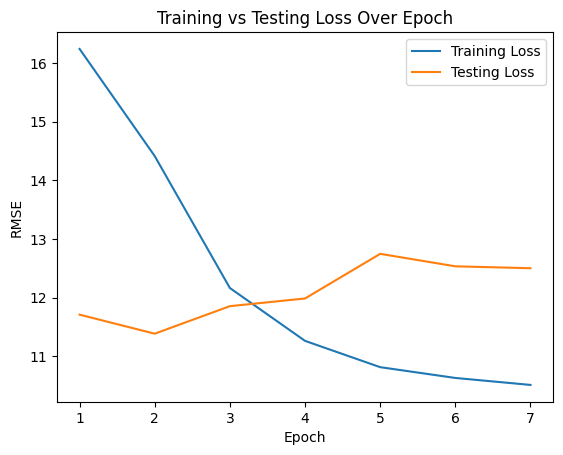

In [113]:
plt.plot(range(1, len(train_losses) + 1), train_losses, label="Training Loss")
plt.plot(range(1, len(train_losses) + 1), test_losses, label="Testing Loss")
plt.xlabel("Epoch") 
plt.ylabel("RMSE")
plt.title("Training vs Testing Loss Over Epoch")
plt.legend()
plt.show()

This is the final RMSE using the 3 predicitons of Load, Solar, and Wind used in the formula as residual_load_predicted = load - (solar + wind) and then used in RMSE formula with the residual_load_orig to get the error

In [114]:
wind = predict_full(wind_model, test_loader)

In [115]:

residual_load_predicted = load - (solar + wind)
residual_load_original = data2['residual_load_orig'].iloc[28000:].values
final_rmse_cnnlstm = root_mean_squared_error(residual_load_original, residual_load_predicted)
print(final_rmse_cnnlstm)

1682.6843741244775


GCN + LSTM

This code loads a weather tensor, replaces missing values with zero, and rearranges it into the format PyTorch expects: samples × channels × height × width. Each channel is then scaled independently to the 0–1 range by flattening it, applying MinMax scaling, and reshaping it back. Finally, only selected channels are kept to form solar_data, and seq_length defines how many past time steps will be used when creating input sequences.

In [116]:
data3 = np.load(r'C:\Users\kaifm\Downloads\weather_stack_mar2023_aug2025.npy')
data3 = np.nan_to_num(data3, nan=0.0)
print(data3.shape)
data3 = np.transpose(data3, (0, 3, 1, 2))  # N, H, W, C -> N, C, H, W
N, C, H, W = data3.shape

# Scale each channel separately
data_scaled = np.zeros_like(data3)
for c in range(C):
    scaler = MinMaxScaler()
    flat = data3[:, c, :, :].reshape(N, -1)
    flat_scaled = scaler.fit_transform(flat)
    data_scaled[:, c, :, :] = flat_scaled.reshape(N, H, W)

keep_channels = [0, 2, 3, 4, 5]  # example
solar_data = data_scaled[:, keep_channels, :, :]
seq_length = 12
print(solar_data.shape)


(30673, 21, 48, 6)
(30673, 5, 21, 48)


This function builds the graph connectivity for an H×W grid. Each cell becomes one graph node. For every node, it creates edges to its right and bottom neighbors, plus the reverse edges so the graph is bidirectional. All edges are collected, converted into a tensor, and returned in the PyTorch Geometric format [2, num_edges], where the first row contains source nodes and the second row contains target nodes.

In [117]:
def grid(H, W):
    """
    Create edge_index for a H x W grid (undirected).
    Returns edge_index of shape [2, num_edges] and optional positions pos=None.
    """
    edges = []
    for i in range(H):
        for j in range(W):
            node = i * W + j
            # right neighbor
            if j < W - 1:
                edges.append([node, node + 1])
                edges.append([node + 1, node])
            # bottom neighbor
            if i < H - 1:
                edges.append([node, node + W])
                edges.append([node + W, node])

    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()  # shape [2, num_edges]
    pos = None  # optional, can store node coordinates if needed
    return edge_index, pos


This function turns every sample in your tensor dataset into a graph that a GCN can process. For each sample, it first reshapes the image-like data so that every grid cell becomes a node containing all channel values as its features. Then it calls grid(H, W) to generate the connectivity of an H×W grid, ensuring each node is linked to its right and bottom neighbors, and converts these edges into the correct integer format. It also attaches the corresponding target value as the graph’s label. Finally, it packages the node features, edges, and label into a PyTorch Geometric Data object and adds it to a list. The result is a list of graphs, one per sample, ready to be used as input for a GCN-LSTM model.

In [118]:
from torch_geometric.data import Data

def create_graph_list(X, y):
    """
    Converts 5D data [N, S, C, H, W] into a list of PyG Graph Data objects.
    Each graph corresponds to one sample (sequence) and flattens S*C features per node.
    """
    graphs = []
    N, S, C, H, W = X.shape  # N samples, S timesteps, C channels, H, W

    for i in range(N):
        sample = X[i]  # [S, C, H, W]

        # Flatten sequence and channels into node features
        # Resulting shape: [H*W, S*C]
        nodes = torch.tensor(sample.reshape(S * C, H * W).T, dtype=torch.float)

        # Create edge_index for a grid of H*W nodes
        edge_index = []
        for r in range(H):
            for c in range(W):
                node = r * W + c
                # Right neighbor
                if c < W - 1:
                    edge_index.append([node, node + 1])
                    edge_index.append([node + 1, node])
                # Bottom neighbor
                if r < H - 1:
                    edge_index.append([node, node + W])
                    edge_index.append([node + W, node])

        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()  # shape [2, num_edges]

        # Target value
        target = torch.tensor([y[i]], dtype=torch.float)

        # Create graph
        data = Data(x=nodes, edge_index=edge_index, y=target)
        graphs.append(data)

    return graphs

This function slices the dataset into train, validation, and test sets while accounting for the sequence length used in the model. Because each sequence needs seq_length past steps, the function subtracts that amount from all the dataset index boundaries to avoid creating incomplete sequences. It then builds the splits by taking continuous chunks for training and by combining two separate intervals for validation and test. Finally, it returns the correctly adjusted X and y arrays for all three splits.

In [119]:
def slice_indices_continuous(X, y, seq_length):
    # Adjust for sequence length
    train_end = 18000 - seq_length
    val_start = 18000 - seq_length
    val_end = 28000 - seq_length
    test_start = 28000 - seq_length

    # Train
    X_train = X[:train_end]
    y_train = y[:train_end]

    # Validation
    X_val = X[val_start:val_end]
    y_val = y[val_start:val_end]

    # Test
    X_test = X[test_start:]
    y_test = y[test_start:]

    return X_train, y_train, X_val, y_val, X_test, y_test

seq_length = 12

x_list = []
y_list = []

for i in range(len(solar_data) - seq_length - 1):
    seq = solar_data[i:i + seq_length]  # (12, 5, 21, 48)
    target = data2['target_solar_1h'].iloc[i + seq_length]
    
    x_list.append(seq)
    y_list.append(target)

X = np.array(x_list, dtype=np.float32)
y = np.array(y_list, dtype=np.float32).reshape(-1, 1)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

# Usage for solar
X_train, y_train, X_val, y_val, X_test, y_test = slice_indices_continuous(
    X, y, seq_length
)

Shape of X: (30660, 12, 5, 21, 48)
Shape of y: (30660, 1)


In [120]:
print("X_train.shape:", X_train.shape)
print("X_val.shape:", X_val.shape)
print("X_test.shape:", X_test.shape)

X_train.shape: (17988, 12, 5, 21, 48)
X_val.shape: (10000, 12, 5, 21, 48)
X_test.shape: (2672, 12, 5, 21, 48)


In [121]:
from torch_geometric.loader import DataLoader
train_graphs = create_graph_list(X_train, y_train)
val_graphs = create_graph_list(X_val, y_val)
test_graphs = create_graph_list(X_test, y_test)

train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True)
val_loader = DataLoader(val_graphs, batch_size=32, shuffle=False)
test_loader = DataLoader(test_graphs, batch_size=32, shuffle=False)

C:\Users\kaifm\AppData\Local\Temp\ipykernel_26012\4282246314.py:35: UserWarning:

Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)



GCN + LSTM Solar

This model combines graph processing with sequence modeling. It begins with two GCN layers that extract spatial features from the graph using the provided edges, applying ReLU and dropout after each layer. After the graph nodes are processed, a global mean pooling step compresses all node features of each graph into a single vector. This pooled vector is then expanded into a sequence dimension and fed into an LSTM, which learns temporal patterns. Finally, a linear layer converts the LSTM output into a single prediction value.

In [122]:
class GCN_LSTM(nn.Module):
    def __init__(self, in_features, gcn_hidden, lstm_hidden, num_layers=2, dropout=0.2):
        super(GCN_LSTM, self).__init__()
        self.gcn1 = GCNConv(in_features, gcn_hidden)
        self.gcn2 = GCNConv(gcn_hidden, gcn_hidden)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.lstm = nn.LSTM(input_size=gcn_hidden, hidden_size=lstm_hidden, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(lstm_hidden, 1)

    def forward(self, x, edge_index, batch):
        x = self.relu(self.gcn1(x, edge_index))
        x = self.dropout(x)
        x = self.relu(self.gcn2(x, edge_index))
        x = self.dropout(x)
        x = global_mean_pool(x, batch)
        x = x.unsqueeze(1)
        out, (hn, cn) = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

In [123]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = GCN_LSTM(in_features = 60, gcn_hidden = 64, lstm_hidden = 256, dropout = 0.2).to(device)
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(params = model.parameters(), lr = 1e-4)
scheduler = ReduceLROnPlateau(optimizer = optimizer, mode = 'min', patience = 3, factor = 0.5)

This loop trains the model and tracks performance. For each epoch, it switches the model to training mode, processes all training batches, computes predictions, calculates loss, backpropagates gradients, and updates the optimizer while accumulating the training error. After finishing the training pass, it computes the average training RMSE. Then it switches to evaluation mode, disables gradient calculation, and runs the model on test batches to compute the average test RMSE. The learning-rate scheduler receives the test error to adjust learning rate if needed. Finally, it prints the epoch’s training and testing errors and stores both for later analysis.

In [124]:
training_losses = []
testing_losses = []
patience = 5
min_delta = 1e-4
best_test_loss = float("inf")
counter = 0

for epoch in range(100):
    model.train()
    running_training_loss = 0
    running_testing_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        outputs = model(data.x, data.edge_index, data.batch)
        loss = loss_function(outputs.view(-1), data.y.view(-1))
        loss.backward()
        optimizer.step()
        running_training_loss += loss.item()
    train_error = running_training_loss/len(train_loader)
    training_losses.append(np.sqrt(train_error))

    model.eval()
    with torch.no_grad():
        for data in test_loader:
            data = data.to(device)
            outputs = model(data.x, data.edge_index, data.batch)
            loss = loss_function(outputs.view(-1), data.y.view(-1))
            running_testing_loss += loss.item()
        final_loss = running_testing_loss/len(test_loader)
        testing_losses.append(np.sqrt(final_loss))
        scheduler.step(final_loss)
    print(f"Epoch : {epoch + 1} ---- Training Loss : {np.sqrt(train_error)} ---- Testing Error : {np.sqrt(final_loss)}")
    if best_test_loss - final_loss > min_delta:
        best_test_loss = final_loss
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print(f"Early stopping at epoch {epoch + 1}")
        break

Epoch : 1 ---- Training Loss : 905.4050282656394 ---- Testing Error : 2344.969515583914
Epoch : 2 ---- Training Loss : 895.2343323051635 ---- Testing Error : 2337.7786289883743
Epoch : 3 ---- Training Loss : 889.8830310326459 ---- Testing Error : 2331.043874137671
Epoch : 4 ---- Training Loss : 884.5156434369492 ---- Testing Error : 2324.507562577963
Epoch : 5 ---- Training Loss : 879.7501165646246 ---- Testing Error : 2318.051890320887
Epoch : 6 ---- Training Loss : 874.2724129621953 ---- Testing Error : 2311.66812177015
Epoch : 7 ---- Training Loss : 870.7453351545352 ---- Testing Error : 2305.3907324606553
Epoch : 8 ---- Training Loss : 866.1678980014834 ---- Testing Error : 2299.1816330050174
Epoch : 9 ---- Training Loss : 863.4739385862628 ---- Testing Error : 2292.9939139225194
Epoch : 10 ---- Training Loss : 858.651978765094 ---- Testing Error : 2286.869523282397
Epoch : 11 ---- Training Loss : 851.5574422625886 ---- Testing Error : 2280.783496332534
Epoch : 12 ---- Training Los

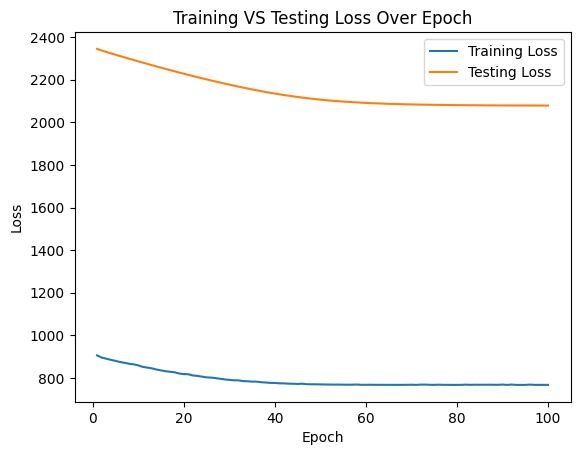

In [125]:
plt.plot(range(1, len(training_losses) + 1), training_losses, label = "Training Loss")
plt.plot(range(1, len(training_losses) + 1), testing_losses, label = "Testing Loss")
plt.legend()
plt.title("Training VS Testing Loss Over Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

This function defines the Optuna objective that evaluates one hyperparameter configuration. It samples learning rate, hidden sizes, dropout, and optimizer type, then builds a GCN-LSTM model with these settings and moves it to the GPU. Based on the sampled optimizer, it creates Adam, SGD, or RMSprop with appropriate parameters. It then trains the model for a small number of epochs: each epoch runs a full training loop with gradient clipping, and after that it computes the validation RMSE by running the model in evaluation mode on the validation loader. The RMSE is reported to Optuna so the trial can be tracked or pruned early if performing poorly. The final returned RMSE is the metric Optuna tries to minimize

In [126]:
def objective(trial):
    lr = trial.suggest_float('lr', 1e-5, 1e-3)
    fc1_size = trial.suggest_int('fc1_size', 64, 256)
    fc2_size = trial.suggest_int('fc2_size', 64, 256)
    dropout = trial.suggest_float('dropout', 0.20, 0.50)
    optimizer = trial.suggest_categorical('optimizer', ['Adam', 'RMSprop', 'SGD'])

    model = GCN_LSTM(in_features = 60, gcn_hidden = fc1_size, lstm_hidden = fc2_size, dropout = dropout).to(device)

    if optimizer == 'Adam':
        optimizer = torch.optim.Adam(params = model.parameters(), lr = lr, weight_decay = 1e-4)
    elif optimizer == 'SGD':
        lr_sgd = trial.suggest_float('lr_sgd', 1e-6, 5e-4)
        optimizer = torch.optim.SGD(params = model.parameters(), lr = lr_sgd, momentum = 0.9,weight_decay = 1e-4)
    else:
        optimizer = torch.optim.RMSprop(params = model.parameters(), lr = lr, weight_decay = 1e-4, alpha = 0.99)

    loss_function = nn.MSELoss()

    for epoch in range(15):
        model.train()
        for data in train_loader:
            data = data.to(device)
            optimizer.zero_grad()
            outputs = model(data.x, data.edge_index, data.batch)
            loss = loss_function(outputs.squeeze(), data.y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        
        val_loss = 0
        model.eval()
        with torch.no_grad():
            for data in val_loader:
                data = data.to(device)
                outputs = model(data.x, data.edge_index, data.batch)
                loss = loss_function(outputs.squeeze(), data.y)
                val_loss += loss.item()
        val_error = val_loss/len(val_loader)
        rmse = np.sqrt(val_error)
        trial.report(rmse, step = epoch)
        if trial.should_prune():
            raise TrialPruned()
    return rmse

In [127]:
study = optuna.create_study(direction = 'minimize')
study.optimize(objective, n_trials = 15)
print("Best Params : ")
print(study.best_params)
print("Best Value")
print(study. best_value)

[I 2026-01-25 16:35:19,199] A new study created in memory with name: no-name-37267618-ee36-4ba0-bc02-3dce63b66022
C:\Users\kaifm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torch\nn\modules\loss.py:610: UserWarning:

Using a target size (torch.Size([32, 1])) that is different to the input size (torch.Size([32])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.

C:\Users\kaifm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torch\nn\modules\loss.py:610: UserWarning:

Using a target size (torch.Size([4, 1])) that is different to the input size (torch.Size([4])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.

C:\Users\kaifm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Pyt

Best Params : 
{'lr': 0.0009685282979293074, 'fc1_size': 99, 'fc2_size': 178, 'dropout': 0.2777366615351363, 'optimizer': 'Adam'}
Best Value
1231.8943161773384


In [128]:
optuna.visualization.plot_optimization_history(study).show()

In [129]:
optuna.visualization.plot_param_importances(study).show()

This code splits the full dataset into train and test periods while making sure the slice boundaries do not exceed the available data length. It first checks the total number of samples and adjusts all index ranges by subtracting the sequence length so temporal sequences remain valid. Two separate ranges are included for training and two for testing. Each range is checked to ensure it falls inside the dataset. Valid slices are collected in lists and then concatenated into final train and test arrays for both X and y. After the split, the code prints the sizes, converts each sample sequence into a graph with create_graph_list, and builds PyTorch Geometric DataLoaders for training and testing. Finally, it prints the shape of one batch to confirm that node features, edges, and targets are correctly formed.

In [130]:
seq_length = 12

# ===================== CREATE SEQUENCES =====================
X_seq = []
y_seq = []

targets = data2['target_solar_1h'].values

for i in range(len(solar_data) - seq_length -1):
    seq = solar_data[i:i + seq_length]   # shape (seq_length, C, H, W)
    target = targets[i + seq_length]     # align target
    X_seq.append(seq)
    y_seq.append(target)

X_seq = np.array(X_seq, dtype=np.float32)  # shape: (N_samples, 12, C, H, W)
y_seq = np.array(y_seq, dtype=np.float32).reshape(-1, 1)

# ===================== SPLIT TRAIN/TEST =====================
def slice_indices(X, y, train_end_idx=28000):
    total_length = min(len(X), len(y))
    train_end = min(train_end_idx - seq_length, total_length)
    
    X_train = X[:train_end]
    y_train = y[:train_end]
    
    X_test = X[train_end:]
    y_test = y[train_end:]
    
    print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
    print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")
    
    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = slice_indices(X_seq, y_seq)


X_train shape: (27988, 12, 5, 21, 48), y_train shape: (27988, 1)
X_test shape: (2672, 12, 5, 21, 48), y_test shape: (2672, 1)


The code converts solar sequences into graphs, where each grid cell is a node connected to its neighbors. The GCN_LSTM model extracts spatial features with GCNs, captures temporal patterns with an LSTM, and predicts a single value per sequence. It trains for 20 epochs using MSE loss, clips gradients, and tracks training and testing losses each epoch

In [131]:
lr = study.best_params['lr']
gcn_hidden = study.best_params['fc1_size']
lstm_hidden = study.best_params['fc2_size']
optimizer = study.best_params['optimizer']
dropout = study.best_params['dropout']
solar_model2 = GCN_LSTM(in_features = 60, gcn_hidden = gcn_hidden , lstm_hidden = lstm_hidden, dropout = dropout).to(device)
if optimizer == 'Adam':
    optimizer = torch.optim.Adam(params = solar_model2.parameters(), lr = lr, weight_decay = 1e-4)
elif optimizer == 'SGD':
    optimizer = torch.optim.SGD(params = solar_model2.parameters(), lr = lr, momentum = 0.9, weight_decay = 1e-4)
else:
    optimizer = torch.optim.RMSprop(params = solar_model2.parameters(), lr = lr, weight_decay = 1e-4, alpha = 0.99)

loss_function = nn.MSELoss()
train_losses = []
test_losses = []
patience = 5
min_delta = 1e-4
best_test_loss = float("inf")
counter = 0

for epoch in range(50):
    solar_model2.train()
    running_training_loss = 0
    running_testing_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        outputs = solar_model2(data.x, data.edge_index, data.batch)
        loss = loss_function(outputs.squeeze(), data.y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(solar_model2.parameters(), 1.0)
        optimizer.step()
        running_training_loss += loss.item()
    error = running_training_loss/len(train_loader)
    train_losses.append(np.sqrt(error))

    solar_model2.eval()
    with torch.no_grad():
        for data in test_loader:
            data = data.to(device)
            outputs = solar_model2(data.x, data.edge_index, data.batch)
            loss = loss_function(outputs.squeeze(), data.y)
            running_testing_loss += loss.item()
        final_loss = running_testing_loss/len(test_loader)
        test_losses.append(np.sqrt(final_loss))
    print(f"Epoch : {epoch + 1} ---- Training Loss : {np.sqrt(error):.4f} ---- Testing Loss : {np.sqrt(final_loss):.4f}")
    if best_test_loss - final_loss > min_delta:
        best_test_loss = final_loss
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print(f"Early stopping at epoch {epoch + 1}")
        break


C:\Users\kaifm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torch\nn\modules\loss.py:610: UserWarning:

Using a target size (torch.Size([32, 1])) that is different to the input size (torch.Size([32])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.

C:\Users\kaifm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torch\nn\modules\loss.py:610: UserWarning:

Using a target size (torch.Size([4, 1])) that is different to the input size (torch.Size([4])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.

C:\Users\kaifm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torch\nn\modules\loss.py:610: UserWarning:

Using a target size (torch.Size([16, 1])) that is

Epoch : 1 ---- Training Loss : 889.1022 ---- Testing Loss : 2306.6044
Epoch : 2 ---- Training Loss : 851.5271 ---- Testing Loss : 2260.9743
Epoch : 3 ---- Training Loss : 822.0703 ---- Testing Loss : 2217.9407
Epoch : 4 ---- Training Loss : 800.0417 ---- Testing Loss : 2179.0000
Epoch : 5 ---- Training Loss : 783.8381 ---- Testing Loss : 2148.1337
Epoch : 6 ---- Training Loss : 774.8774 ---- Testing Loss : 2124.5622
Epoch : 7 ---- Training Loss : 770.3922 ---- Testing Loss : 2109.2575
Epoch : 8 ---- Training Loss : 768.4935 ---- Testing Loss : 2099.0121
Epoch : 9 ---- Training Loss : 768.1308 ---- Testing Loss : 2092.3253
Epoch : 10 ---- Training Loss : 767.0549 ---- Testing Loss : 2089.0296
Epoch : 11 ---- Training Loss : 767.2672 ---- Testing Loss : 2087.2779
Epoch : 12 ---- Training Loss : 766.8210 ---- Testing Loss : 2084.6308
Epoch : 13 ---- Training Loss : 767.1622 ---- Testing Loss : 2085.5732
Epoch : 14 ---- Training Loss : 768.3197 ---- Testing Loss : 2085.3870
Epoch : 15 ----

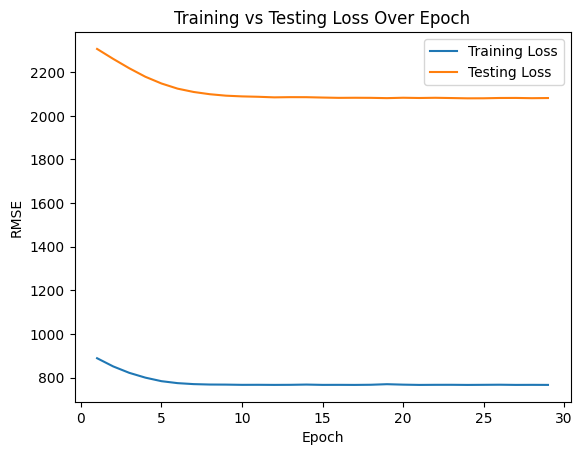

In [132]:
plt.plot(range(1, len(train_losses) + 1), train_losses, label="Training Loss")
plt.plot(range(1, len(train_losses) + 1), test_losses, label="Testing Loss")
plt.xlabel("Epoch") 
plt.ylabel("RMSE")
plt.title("Training vs Testing Loss Over Epoch")
plt.legend()
plt.show()


In [133]:
def predict_full(model, data_loader):
    model.eval()
    all_outputs = []
    with torch.no_grad():
        for batch in data_loader:            # batch is a single Data object
            batch = batch.to(device)         # move all data to GPU if available
            out = model(batch.x, batch.edge_index, batch.batch)
            all_outputs.append(out.cpu().numpy())
    return np.concatenate(all_outputs, axis=0)


In [134]:
solar2 = predict_full(solar_model2, test_loader)

Wind GCN + LSTM

This function splits the data into training, validation, and testing sets, taking into account the sequence length for time series. It uses predefined index ranges: the first part for training, two segments for validation, and two segments for testing. Each set is sliced from X and y accordingly and returned.

In [135]:
seq_length = 12
keep_channels = [0, 1]
wind_data = data_scaled[:, keep_channels, :, :]  # shape: (N, 2, H, W)
targets = data2['target_wind_1h'].values

# ===== Create sequences =====
X_seq = []
y_seq = []
for i in range(len(wind_data) - seq_length - 1):
    seq = wind_data[i:i + seq_length]  # (12, 2, H, W)
    target = targets[i + seq_length]   # align target
    X_seq.append(seq)
    y_seq.append(target)

X_seq = np.array(X_seq, dtype=np.float32)  # shape: (num_samples, 12, 2, H, W)
y_seq = np.array(y_seq, dtype=np.float32).reshape(-1, 1)

# ===== Split sequences =====
def slice_indices(X, y):
    train_end = 18000 - seq_length
    val_start = 18000 - seq_length
    val_end = 28000 - seq_length
    test_start = 28000 - seq_length

    X_train = X[:train_end]
    y_train = y[:train_end]

    X_val = X[val_start:val_end]
    y_val = y[val_start:val_end]

    X_test = X[test_start:]
    y_test = y[test_start:]

    return X_train, y_train, X_val, y_val, X_test, y_test

# ===== Usage =====
X_train, y_train, X_val, y_val, X_test, y_test = slice_indices(X_seq, y_seq)

print("X_train.shape:", X_train.shape)
print("X_val.shape:", X_val.shape)
print("X_test.shape:", X_test.shape)


X_train.shape: (17988, 12, 2, 21, 48)
X_val.shape: (10000, 12, 2, 21, 48)
X_test.shape: (2672, 12, 2, 21, 48)


In [136]:
train_graphs = create_graph_list(X_train, y_train)
val_graphs = create_graph_list(X_val, y_val)
test_graphs = create_graph_list(X_test, y_test)

train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True)
val_loader = DataLoader(val_graphs, batch_size=32, shuffle=False)
test_loader = DataLoader(test_graphs, batch_size=32, shuffle=False)

In [137]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = GCN_LSTM(in_features = 24, gcn_hidden = 64, lstm_hidden = 256, dropout = 0.2).to(device) 
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(params = model.parameters(), lr = 1e-4)
scheduler = ReduceLROnPlateau(optimizer = optimizer, mode = 'min', patience = 3, factor = 0.5)

This loop trains and evaluates your GCN_LSTM model for 100 epochs. For each epoch, it goes through all training batches, computes predictions, calculates MSE loss, backpropagates, and updates weights. After training, it evaluates on the test set without gradients, accumulates the loss, and updates a learning rate scheduler. Finally, it prints and records the RMSE for both training and testing.

In [138]:
training_losses = []
testing_losses = []
patience = 5
min_delta = 1e-4
best_test_loss = float("inf")
counter = 0

for epoch in range(100):
    model.train()
    running_training_loss = 0
    running_testing_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        outputs = model(data.x, data.edge_index, data.batch)
        loss = loss_function(outputs.squeeze(), data.y)
        loss.backward()
        optimizer.step()
        running_training_loss += loss.item()
    train_error = running_training_loss/len(train_loader)
    training_losses.append(np.sqrt(train_error))

    model.eval()
    with torch.no_grad():
        for data in test_loader:
            data = data.to(device)
            outputs = model(data.x, data.edge_index, data.batch)
            loss = loss_function(outputs, data.y)
            running_testing_loss += loss.item()
        final_loss = running_testing_loss/len(test_loader)
        testing_losses.append(np.sqrt(final_loss))
        scheduler.step(final_loss)
    print(f"Epoch : {epoch + 1} ---- Training Loss : {np.sqrt(train_error)} ---- Testing Error : {np.sqrt(final_loss)}")
    if best_test_loss - final_loss > min_delta:
        best_test_loss = final_loss
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print(f"Early stopping at epoch {epoch + 1}")
        break

Epoch : 1 ---- Training Loss : 18.474604134432532 ---- Testing Error : 11.919384867061948
Epoch : 2 ---- Training Loss : 15.689859633630117 ---- Testing Error : 12.372349500643454
Epoch : 3 ---- Training Loss : 15.668398005255716 ---- Testing Error : 12.450033253643385
Epoch : 4 ---- Training Loss : 15.67826963336811 ---- Testing Error : 12.423222538922412
Epoch : 5 ---- Training Loss : 15.66997282083603 ---- Testing Error : 12.433592167576522
Epoch : 6 ---- Training Loss : 15.681823521506091 ---- Testing Error : 12.419834952194197
Early stopping at epoch 6


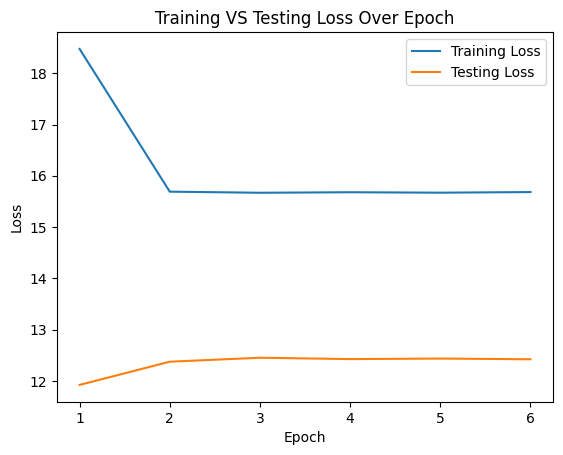

In [139]:
plt.plot(range(1, len(training_losses) + 1), training_losses, label = "Training Loss")
plt.plot(range(1, len(training_losses) + 1), testing_losses, label = "Testing Loss")
plt.legend()
plt.title("Training VS Testing Loss Over Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

This function runs an Optuna trial: it samples hyperparameters, builds a GCN_LSTM model, trains it on train_loader for 5 epochs, evaluates RMSE on val_loader, reports it to Optuna, and allows pruning of poor trials, returning the final validation RMSE.

In [140]:
def objective(trial):
    lr = trial.suggest_float('lr', 1e-5, 1e-3)
    fc1_size = trial.suggest_int('fc1_size', 64, 256)
    fc2_size = trial.suggest_int('fc2_size', 64, 256)
    dropout = trial.suggest_float('dropout', 0.20, 0.50)
    optimizer = trial.suggest_categorical('optimizer', ['Adam', 'RMSprop', 'SGD'])

    model = GCN_LSTM(in_features = 24, gcn_hidden = fc1_size, lstm_hidden = fc2_size, dropout = dropout).to(device) 

    if optimizer == 'Adam':
        optimizer = torch.optim.Adam(params = model.parameters(), lr = lr, weight_decay = 1e-4)
    elif optimizer == 'SGD':
        lr_sgd = trial.suggest_float('lr_sgd', 1e-6, 5e-4)
        optimizer = torch.optim.SGD(params = model.parameters(), lr = lr_sgd, momentum = 0.9,weight_decay = 1e-4)
    else:
        optimizer = torch.optim.RMSprop(params = model.parameters(), lr = lr, weight_decay = 1e-4, alpha = 0.99)

    loss_function = nn.MSELoss()

    for epoch in range(15):
        model.train()
        for data in train_loader:
            data = data.to(device)
            optimizer.zero_grad()
            outputs = model(data.x, data.edge_index, data.batch)
            loss = loss_function(outputs.squeeze(), data.y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        
        val_loss = 0
        model.eval()
        with torch.no_grad():
            for data in val_loader:
                data = data.to(device)
                outputs = model(data.x, data.edge_index, data.batch)
                loss = loss_function(outputs.squeeze(), data.y)
                val_loss += loss.item()
        val_error = val_loss/len(val_loader)
        rmse = np.sqrt(val_error)
        trial.report(rmse, step = epoch)
        if trial.should_prune():
            raise TrialPruned()
    return rmse

In [141]:
study = optuna.create_study(direction = 'minimize')
study.optimize(objective, n_trials = 15)
print("Best Params : ")
print(study.best_params)
print("Best Value")
print(study. best_value)

[I 2026-01-25 17:09:33,283] A new study created in memory with name: no-name-1d068c7e-98cb-4714-bb63-8c3180692794
[I 2026-01-25 17:12:22,830] Trial 0 finished with value: 16.249416875982156 and parameters: {'lr': 0.0007768904397856854, 'fc1_size': 154, 'fc2_size': 108, 'dropout': 0.3008576044183715, 'optimizer': 'Adam'}. Best is trial 0 with value: 16.249416875982156.
[I 2026-01-25 17:14:07,231] Trial 1 finished with value: 16.24124356547932 and parameters: {'lr': 0.000869208987045156, 'fc1_size': 86, 'fc2_size': 190, 'dropout': 0.21168362414733422, 'optimizer': 'RMSprop'}. Best is trial 1 with value: 16.24124356547932.
[I 2026-01-25 17:15:59,053] Trial 2 finished with value: 16.24403879864165 and parameters: {'lr': 0.0006225231671204181, 'fc1_size': 95, 'fc2_size': 106, 'dropout': 0.22794017350044693, 'optimizer': 'Adam'}. Best is trial 1 with value: 16.24124356547932.
[I 2026-01-25 17:17:43,874] Trial 3 finished with value: 16.28486102199394 and parameters: {'lr': 0.00049722965210817

Best Params : 
{'lr': 0.000869208987045156, 'fc1_size': 86, 'fc2_size': 190, 'dropout': 0.21168362414733422, 'optimizer': 'RMSprop'}
Best Value
16.24124356547932


In [142]:
optuna.visualization.plot_optimization_history(study).show()

In [143]:
optuna.visualization.plot_param_importances(study).show()

This code splits the wind dataset into training and testing sets using the given sequence length, ensuring slices don’t exceed the dataset length. It then creates graph representations for each sample, builds PyTorch Geometric DataLoaders for batching, and prints shapes to verify that the graphs and batches are correctly formed.

In [144]:
seq_length = 12
keep_channels = [0, 1]
wind_data = data_scaled[:, keep_channels, :, :]  # shape: (N, 2, H, W)
targets = data2['target_wind_1h'].values        # shape: (N,)

# ===== Create sequences =====
X_seq = []
y_seq = []
for i in range(len(wind_data) - seq_length - 1):
    seq = wind_data[i:i + seq_length]  # (12, 2, H, W)
    target = targets[i + seq_length]   # align target with end of sequence
    X_seq.append(seq)
    y_seq.append(target)

X_seq = np.array(X_seq, dtype=np.float32)  # shape: (num_samples, 12, 2, H, W)
y_seq = np.array(y_seq, dtype=np.float32).reshape(-1, 1)

# ===== Slice train/test =====
def slice_indices(X, y, train_end_idx=28000):
    train_end = min(train_end_idx - seq_length, len(X))
    
    # Train
    X_train = X[:train_end]
    y_train = y[:train_end]
    
    # Test
    X_test = X[train_end:]
    y_test = y[train_end:]
    
    print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
    print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")
    
    return X_train, y_train, X_test, y_test

# ===== Usage =====
X_train, y_train, X_test, y_test = slice_indices(X_seq, y_seq)

print("\n" + "="*50)
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("="*50 + "\n")

# ===== Create graph lists =====
train_graphs = create_graph_list(X_train, y_train)
test_graphs = create_graph_list(X_test, y_test)

print(f"Number of training graphs: {len(train_graphs)}")
print(f"Number of testing graphs: {len(test_graphs)}")

# ===== Create DataLoaders =====
train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True)
test_loader = DataLoader(test_graphs, batch_size=32, shuffle=False)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of testing batches: {len(test_loader)}")

# ===== Verify a sample batch =====
for batch in train_loader:
    print("\nSample batch info:")
    print(f"  Batch x shape: {batch.x.shape}")
    print(f"  Batch edge_index shape: {batch.edge_index.shape}")
    print(f"  Batch y shape: {batch.y.shape}")
    break

X_train shape: (27988, 12, 2, 21, 48), y_train shape: (27988, 1)
X_test shape: (2672, 12, 2, 21, 48), y_test shape: (2672, 1)

X_train shape: (27988, 12, 2, 21, 48)
y_train shape: (27988, 1)
X_test shape: (2672, 12, 2, 21, 48)
y_test shape: (2672, 1)

Number of training graphs: 27988
Number of testing graphs: 2672
Number of training batches: 875
Number of testing batches: 84

Sample batch info:
  Batch x shape: torch.Size([32256, 24])
  Batch edge_index shape: torch.Size([2, 124608])
  Batch y shape: torch.Size([32, 1])


This code trains the GCN-LSTM model for 20 epochs using the best hyperparameters from Optuna. In each epoch, it first loops over the training data to compute predictions, calculate MSE loss, backpropagate, clip gradients, and update weights, then computes the training RMSE. After that, it evaluates the model on the test data without updating weights to calculate test RMSE. Finally, it prints the training and testing RMSE for each epoch, allowing to monitor the model’s performance over time.

In [145]:
lr = study.best_params['lr']
gcn_hidden = study.best_params['fc1_size']
lstm_hidden = study.best_params['fc2_size']
optimizer = study.best_params['optimizer']
dropout = study.best_params['dropout']
wind_model2 = GCN_LSTM(in_features = 24, gcn_hidden = gcn_hidden , lstm_hidden = lstm_hidden, dropout = dropout).to(device) 
if optimizer == 'Adam':
    optimizer = torch.optim.Adam(params = wind_model2.parameters(), lr = lr, weight_decay = 1e-4)
elif optimizer == 'SGD':
    optimizer = torch.optim.SGD(params = wind_model2.parameters(), lr = lr, momentum = 0.9, weight_decay = 1e-4)
else:
    optimizer = torch.optim.RMSprop(params = wind_model2.parameters(), lr = lr, weight_decay = 1e-4, alpha = 0.99)

loss_function = nn.MSELoss()
train_losses = []
test_losses = []
patience = 5
min_delta = 1e-4
best_test_loss = float("inf")
counter = 0

for epoch in range(50):
    wind_model2.train()
    running_training_loss = 0
    running_testing_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        outputs = wind_model2(data.x, data.edge_index, data.batch)
        loss = loss_function(outputs.squeeze(), data.y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(wind_model2.parameters(), 1.0)
        optimizer.step()
        running_training_loss += loss.item()
    error = running_training_loss/len(train_loader)
    train_losses.append(np.sqrt(error))

    wind_model2.eval()
    with torch.no_grad():
        for data in test_loader:
            data = data.to(device)
            outputs = wind_model2(data.x, data.edge_index, data.batch)
            loss = loss_function(outputs.squeeze(), data.y)
            running_testing_loss += loss.item()
        final_loss = running_testing_loss/len(test_loader)
        test_losses.append(np.sqrt(final_loss))
    print(f"Epoch : {epoch + 1} ---- Training Loss : {np.sqrt(error):.4f} ---- Testing Loss : {np.sqrt(final_loss):.4f}")
    if best_test_loss - final_loss > min_delta:
        best_test_loss = final_loss
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print(f"Early stopping at epoch {epoch + 1}")
        break

C:\Users\kaifm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torch\nn\modules\loss.py:610: UserWarning:

Using a target size (torch.Size([32, 1])) that is different to the input size (torch.Size([32])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.

C:\Users\kaifm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torch\nn\modules\loss.py:610: UserWarning:

Using a target size (torch.Size([20, 1])) that is different to the input size (torch.Size([20])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.

C:\Users\kaifm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torch\nn\modules\loss.py:610: UserWarning:

Using a target size (torch.Size([16, 1])) that 

Epoch : 1 ---- Training Loss : 15.9743 ---- Testing Loss : 12.5694
Epoch : 2 ---- Training Loss : 15.8971 ---- Testing Loss : 12.3937
Epoch : 3 ---- Training Loss : 15.8913 ---- Testing Loss : 12.2309
Epoch : 4 ---- Training Loss : 15.8890 ---- Testing Loss : 12.3316
Epoch : 5 ---- Training Loss : 15.8902 ---- Testing Loss : 12.4709
Epoch : 6 ---- Training Loss : 15.8931 ---- Testing Loss : 12.6289
Epoch : 7 ---- Training Loss : 15.8938 ---- Testing Loss : 12.7426
Epoch : 8 ---- Training Loss : 15.8951 ---- Testing Loss : 12.3949
Early stopping at epoch 8


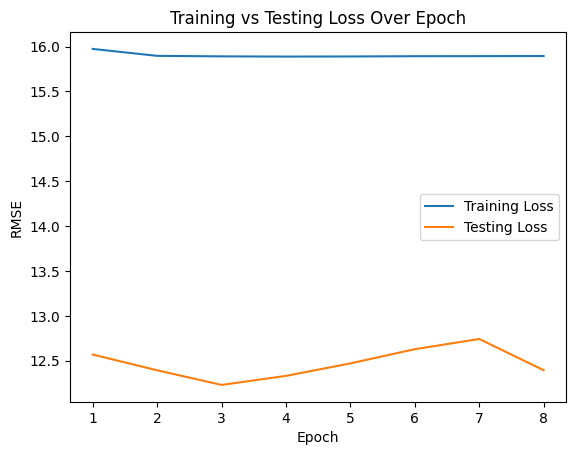

In [146]:
plt.plot(range(1, len(train_losses) + 1), train_losses, label="Training Loss")
plt.plot(range(1, len(train_losses) + 1), test_losses, label="Testing Loss")
plt.xlabel("Epoch") 
plt.ylabel("RMSE")
plt.title("Training vs Testing Loss Over Epoch")
plt.legend()
plt.show()

In [147]:
wind2 = predict_full(wind_model2, test_loader)

In [148]:
residual_load_predicted = load - (solar2 + wind2)
residual_load_original = data2[['residual_load_orig']].iloc[28000:, :].values
final_rmse_gcnlstm = root_mean_squared_error(residual_load_original, residual_load_predicted)
print(final_rmse_gcnlstm)

2050.2561764926572


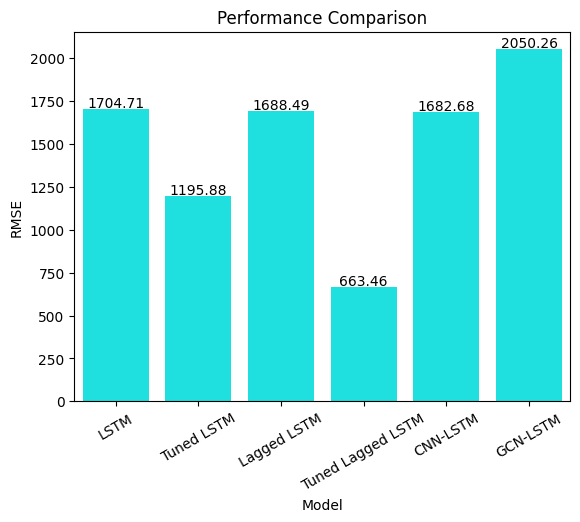

In [183]:
final_data = {
    "model": ["LSTM", "Tuned LSTM", "Lagged LSTM", "Tuned Lagged LSTM", "CNN-LSTM", "GCN-LSTM"],
    "RMSE": [
        lstm_testing_losses[-1],
        tuned_lstm_test_losses[-1],
        lagged_lstm_testing_losses[-1],
        lagged_tuned_lstm_test_losses[-1],
        final_rmse_cnnlstm,
        final_rmse_gcnlstm
    ]
}

df = pd.DataFrame(final_data)
ax = sns.barplot(data = df, x = "model", y = "RMSE", color = "cyan")
for p in ax.patches:
    height = p.get_height()
    ax.text(x = p.get_x() + p.get_width()/2,
            y = height + 10,
            s = f"{height:.2f}",
            ha = "center")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("Performance Comparison")
plt.xticks(rotation = 30)
plt.show()